In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 0. Utils 

In [68]:
from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree, BivariateARTreeBis
from ctw.tree import view_tree
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt

from ctw.models import (
    Quantizer,
    LiveARTree,
    BivariateQuantizer,
    BivariateARTree,
    BivariateARTreeBis,
)
from ctw.tree import view_tree


def standardize_train_test(x, split_ratio=0.7):
    x = np.asarray(x, dtype=float)
    split_idx = int(split_ratio * len(x))
    x_train = x[:split_idx]
    x_test = x[split_idx:]

    mu = np.mean(x_train)
    sigma = np.std(x_train)
    if sigma == 0:
        sigma = 1.0

    x_train_std = (x_train - mu) / sigma
    x_test_std = (x_test - mu) / sigma

    return x_train_std, x_test_std, mu, sigma, split_idx


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))
def lag1_predictions_1step(x_train, x_test):
    preds = np.empty_like(x_test, dtype=float)
    preds[0] = x_train[-1]
    if len(x_test) > 1:
        preds[1:] = x_test[:-1]
    return preds


def lag1_forecast_k(history_x, k):
    last_val = float(history_x[-1])
    return np.full(k, last_val, dtype=float)


def fit_ar_ols(x_train, p=2, verbose=True):
    x_train = np.asarray(x_train, dtype=float)
    if len(x_train) <= p:
        raise ValueError(f"Série trop courte pour fit AR({p})")

    if verbose:
        print(f"[AR] Fitting AR({p}) sur {len(x_train)} points de train...")

    Y = x_train[p:]
    X = []
    for t in range(p, len(x_train)):
        row = [1.0] + [x_train[t - i] for i in range(1, p + 1)]
        X.append(row)

    X = np.asarray(X, dtype=float)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)

    intercept = float(beta[0])
    coefs = np.asarray(beta[1:], dtype=float)

    if verbose:
        print(f"[AR] Fit terminé. intercept={intercept:.4f}, coefs={coefs}")

    return intercept, coefs


def ar_predict_next(history_x, intercept, coefs):
    p = len(coefs)
    history_x = np.asarray(history_x, dtype=float)
    lags = np.array([history_x[-i] for i in range(1, p + 1)], dtype=float)
    return float(intercept + np.dot(coefs, lags))


def ar_predictions_1step(x_train, x_test, p=2):
    intercept, coefs = fit_ar_ols(x_train, p=p)
    full = np.concatenate([x_train, x_test])

    preds = []
    start = len(x_train)
    for t in range(start, len(full)):
        preds.append(ar_predict_next(full[:t], intercept, coefs))
    return np.asarray(preds, dtype=float)


def ar_forecast_k(history_x, k, intercept, coefs):
    history = list(np.asarray(history_x, dtype=float))
    preds = []
    for _ in range(k):
        pred = ar_predict_next(history, intercept, coefs)
        preds.append(pred)
        history.append(pred)
    return np.asarray(preds, dtype=float)

def fit_univariate_tree(x_train, order=2, max_depth=2, n_passes=4, verbose=True):
    if verbose:
        print(
            f"[Univariate CTW] Initialisation du modèle "
            f"(order={order}, max_depth={max_depth}, n_passes={n_passes})"
        )

    quantizer = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    ctw = LiveARTree(
        max_depth=max_depth,
        order=order,
        constant_term=True,
        quantizer=quantizer,
        beta=0.5,
    )

    iterator_passes = range(n_passes)
    if verbose:
        iterator_passes = tqdm(iterator_passes, desc="[Univariate CTW] Passes train")

    for _ in iterator_passes:
        iterator_t = range(order, len(x_train))
        if verbose:
            iterator_t = tqdm(
                iterator_t,
                desc="[Univariate CTW] Observations",
                leave=False,
            )

        for t in iterator_t:
            ctw.observe(x_train[t])

    if verbose:
        print("[Univariate CTW] Fit terminé.")

    return ctw, quantizer


def univariate_predictions_1step(
    x,
    online=False,
    plot_tree=False,
    order=2,
    max_depth=2,
    split_ratio=0.7,
    verbose=True,
):
    if verbose:
        print("[Univariate CTW] Préparation des données...")

    x_train, x_test, mu, sigma, split_idx = standardize_train_test(x, split_ratio=split_ratio)

    if verbose:
        print(f"[Univariate CTW] Train={len(x_train)} | Test={len(x_test)}")

    ctw, quantizer = fit_univariate_tree(
        x_train=x_train,
        order=order,
        max_depth=max_depth,
        n_passes=4,
        verbose=verbose,
    )

    full = np.concatenate([x_train, x_test])
    preds = []
    actuals = []

    iterator = range(len(x_train), len(full))
    if verbose:
        iterator = tqdm(iterator, desc="[Univariate CTW] Prédictions test")

    for t in iterator:
        history = full[t - order:t]
        pred = ctw.predict(history)
        preds.append(pred)
        actuals.append(full[t])

        if online:
            ctw.observe(full[t])

    preds = np.asarray(preds, dtype=float)
    actuals = np.asarray(actuals, dtype=float)

    res = {
        "predictions": preds,
        "actuals": actuals,
        "mse": mse(actuals, preds),
        "mae": mae(actuals, preds),
        "tree": ctw,
        "quantizer": quantizer,
        "mu": mu,
        "sigma": sigma,
        "split_idx": split_idx,
    }

    if verbose:
        print(f"[Univariate CTW] Test MSE: {res['mse']:.6f}")
        print(f"[Univariate CTW] Test MAE: {res['mae']:.6f}")

    if plot_tree:
        view_tree(ctw.tree, quantizer=quantizer)

    return res


def univariate_forecast_k_from_history(history_x, k, order=2, max_depth=2):
    """
    history_x doit déjà être standardisée.
    On refit un modèle univarié sur l'historique disponible puis forecast récursif.
    """
    ctw, _ = fit_univariate_tree(
        x_train=np.asarray(history_x, dtype=float),
        order=order,
        max_depth=max_depth,
        n_passes=4,
    )

    history = list(np.asarray(history_x, dtype=float))
    preds = []
    for _ in range(k):
        h = np.asarray(history[-order:], dtype=float)
        pred = ctw.predict(h)
        preds.append(pred)
        history.append(pred)

    return np.asarray(preds, dtype=float)

def univariate_forecast_k_with_fitted_tree(
    tree,
    history_x,
    k,
    order=2,
):
    """
    Forecast récursif à k pas avec un arbre déjà fit sur le train.
    history_x doit contenir tout l'historique disponible jusqu'à l'origine t.
    """
    history = list(np.asarray(history_x, dtype=float))
    preds = []

    for _ in range(k):
        h = np.asarray(history[-order:], dtype=float)
        pred = tree.predict(h)
        preds.append(pred)
        history.append(pred)

    return np.asarray(preds, dtype=float)

def context_to_regime_ids(contexts):
    mapping = {}
    ids = []
    next_id = 0
    for ctx in contexts:
        ctx = tuple(ctx)
        if ctx not in mapping:
            mapping[ctx] = next_id
            next_id += 1
        ids.append(mapping[ctx])
    return np.asarray(ids), mapping

def regime_switch_mask(regime_ids):
    regime_ids = np.asarray(regime_ids)
    if len(regime_ids) == 0:
        return np.array([], dtype=bool)
    out = np.zeros(len(regime_ids), dtype=bool)
    out[1:] = regime_ids[1:] != regime_ids[:-1]
    return out

def add_regime_background(ax, regime_ids, x_offset=0, alpha=0.22):
    regime_ids = np.asarray(regime_ids)
    if len(regime_ids) == 0:
        return

    unique_regimes = np.unique(regime_ids)
    colors = generate_distinct_colors(len(unique_regimes))
    color_map = {r: colors[i] for i, r in enumerate(unique_regimes)}

    start = 0
    current = regime_ids[0]

    for i in range(1, len(regime_ids)):
        if regime_ids[i] != current:
            ax.axvspan(
                x_offset + start,
                x_offset + i,
                color=color_map[current],
                alpha=alpha,
                linewidth=0,
            )
            start = i
            current = regime_ids[i]

    ax.axvspan(
        x_offset + start,
        x_offset + len(regime_ids),
        color=color_map[current],
        alpha=alpha,
        linewidth=0,
    )

import colorsys

def generate_distinct_colors(n):
    colors = []
    golden_ratio = 0.618033988749895
    h = 0.0
    for _ in range(n):
        h = (h + golden_ratio) % 1
        s = 0.65
        v = 0.9
        colors.append(colorsys.hsv_to_rgb(h, s, v))
    return colors

def bivariate_forecast_k_with_fitted_tree(
    tree,
    history_x,
    history_y,
    k,
    future_y=None,
    use_future_y=True,
    order=2,
    max_depth=3,
):
    """
    Forecast récursif à k pas avec un arbre bivarié déjà fit sur le train.
    """
    x_hist = list(np.asarray(history_x, dtype=float))
    y_hist = list(np.asarray(history_y, dtype=float))
    preds = []

    hist_len = max(max_depth, order)

    if future_y is None:
        future_y = np.full(k, y_hist[-1], dtype=float)
    else:
        future_y = np.asarray(future_y, dtype=float)

    for step in range(k):
        history = np.array([
            x_hist[-hist_len:],
            y_hist[-hist_len:],
        ], dtype=float)

        pred = tree.predict(history)
        preds.append(pred)
        x_hist.append(pred)

        if use_future_y:
            y_hist.append(future_y[step])
        else:
            y_hist.append(y_hist[-1])

    return np.asarray(preds, dtype=float)

def predict_univariate(
    x,
    online=False,
    plot_tree=False,
    k_steps=None,
    n_random_origins=100,
    seed=42,
    verbose=True,
):
    if k_steps is None:
        return univariate_predictions_1step(
            x=x,
            online=online,
            plot_tree=plot_tree,
            verbose=verbose,
        )

    if isinstance(k_steps, int):
        k_steps = [k_steps]

    rng = np.random.default_rng(seed)
    x_train, x_test, mu, sigma, split_idx = standardize_train_test(x, split_ratio=0.7)
    x_std = np.concatenate([x_train, x_test])

    results = {}

    for k in k_steps:
        if verbose:
            print(f"[Univariate CTW] Évaluation k-step avec k={k}")

        candidate_origins = np.arange(split_idx, len(x_std) - k)
        n_use = min(n_random_origins, len(candidate_origins))
        origins = rng.choice(candidate_origins, size=n_use, replace=False)

        mses = []
        maes = []

        iterator = origins
        if verbose:
            iterator = tqdm(origins, desc=f"[Univariate CTW] Origines k={k}")

        for t in iterator:
            history_x = x_std[:t]
            true_future = x_std[t:t + k]
            pred_future = univariate_forecast_k_from_history(history_x, k)
            mses.append(mse(true_future, pred_future))
            maes.append(mae(true_future, pred_future))

        results[k] = {
            "mse": float(np.mean(mses)),
            "mae": float(np.mean(maes)),
            "n_origins": n_use,
        }

        if verbose:
            print(
                f"[Univariate CTW] k={k} | "
                f"MSE={results[k]['mse']:.6f} | "
                f"MAE={results[k]['mae']:.6f}"
            )

    return results

In [76]:
def fit_bivariate_tree(
    x_train,
    y_train,
    order=2,
    max_depth=3,
    verbose=True,
):
    if verbose:
        print(
            f"[Bivariate CTW] Initialisation du modèle "
            f"(order={order}, max_depth={max_depth})"
        )

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    thresholds = np.array([qx, qy], dtype=float)

    bq = BivariateQuantizer(thresholds=thresholds)
    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        quantizer=bq,
        beta=0.5,
    )

    iterator = zip(x_train, y_train)
    if verbose:
        iterator = tqdm(
            list(zip(x_train, y_train)),
            desc="[Bivariate CTW] Observations train",
        )

    for x_i, y_i in iterator:
        tree.observe(x_i, y_i)

    if verbose:
        print("[Bivariate CTW] Fit terminé.")

    return tree, bq


def bivariate_predictions_1step(
    x,
    y,
    online=False,
    plot_tree=False,
    order=2,
    max_depth=3,
    split_ratio=0.7,
    verbose=True,
):
    if verbose:
        print("[Bivariate CTW] Préparation des données...")

    x_train, x_test, mu_x, sigma_x, split_idx = standardize_train_test(x, split_ratio=split_ratio)
    y_train, y_test, mu_y, sigma_y, _ = standardize_train_test(y, split_ratio=split_ratio)

    if verbose:
        print(f"[Bivariate CTW] Train={len(x_train)} | Test={len(x_test)}")

    tree, bq = fit_bivariate_tree(
        x_train=x_train,
        y_train=y_train,
        order=order,
        max_depth=max_depth,
        verbose=verbose,
    )

    preds = []
    actuals = []

    x_seen = list(x_train)
    y_seen = list(y_train)
    hist_len = max(max_depth, order)

    iterator = zip(x_test, y_test)
    if verbose:
        iterator = tqdm(iterator, total=len(x_test), desc="[Bivariate CTW] Prédictions test")

    for x_i, y_i in iterator:
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        pred = tree.predict(history)
        preds.append(pred)
        actuals.append(x_i)

        x_seen.append(x_i)
        y_seen.append(y_i)

        if online:
            tree.observe(x_i, y_i)

    preds = np.asarray(preds, dtype=float)
    actuals = np.asarray(actuals, dtype=float)

    res = {
        "predictions": preds,
        "actuals": actuals,
        "mse": mse(actuals, preds),
        "mae": mae(actuals, preds),
        "tree": tree,
        "quantizer": bq,
        "mu_x": mu_x,
        "sigma_x": sigma_x,
        "mu_y": mu_y,
        "sigma_y": sigma_y,
        "split_idx": split_idx,
    }

    if verbose:
        print(f"[Bivariate CTW] Test MSE: {res['mse']:.6f}")
        print(f"[Bivariate CTW] Test MAE: {res['mae']:.6f}")

    if plot_tree:
        view_tree(tree.tree, quantizer=bq)

    return res

def fit_univariate_for_trace(
    seq_x,
    split=0.7,
    order=2,
    max_depth=2,
    beta=0.5,
    constant_term=True,
    n_passes_train=4,
):
    x = np.asarray(seq_x, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    if std_x == 0:
        std_x = 1.0

    x_scaled = (x - mu_x) / std_x
    x_train = x_scaled[:split_idx]

    q = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    tree = LiveARTree(
        max_depth=max_depth,
        order=order,
        constant_term=constant_term,
        quantizer=q,
        beta=beta,
    )

    for _ in range(n_passes_train):
        for t in range(order, len(x_train)):
            tree.observe(float(x_train[t]))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": q,
    }


def fit_bivariate_for_trace(
    seq_x,
    seq_y,
    split=0.7,
    order=2,
    max_depth=3,
    beta=0.5,
    constant_term=False,
):
    x = np.asarray(seq_x, dtype=float)
    y = np.asarray(seq_y, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    y_train_raw = y[:split_idx]

    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    mu_y = y_train_raw.mean()
    std_y = y_train_raw.std()

    if std_x == 0:
        std_x = 1.0
    if std_y == 0:
        std_y = 1.0

    x_scaled = (x - mu_x) / std_x
    y_scaled = (y - mu_y) / std_y

    x_train = x_scaled[:split_idx]
    y_train = y_scaled[:split_idx]

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    bq = BivariateQuantizer(thresholds=np.array([qx, qy], dtype=float))

    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        constant_term=constant_term,
        quantizer=bq,
        beta=beta,
    )

    for x_i, y_i in zip(x_train, y_train):
        tree.observe(float(x_i), float(y_i))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "y_scaled": y_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "mu_y": mu_y,
        "std_y": std_y,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": bq,
    }


def _select_node_univariate(tree, history):
    history = np.asarray(history, dtype=float)[::-1]
    context_to_navigate = [tree.quantizer.quantize(v) for v in history[:tree.max_depth]][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node


def _select_node_bivariate(tree, history):
    history = np.asarray(history, dtype=float)[:, ::-1]
    bi_context = [history[:tree.max_depth, k] for k in range(history.shape[1])]
    context_to_navigate = [tree.quantizer.quantize(v) for v in bi_context][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node

def trace_univariate_regimes(seq_x, split=0.7, online=False):
    fit = fit_univariate_for_trace(seq_x, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    split_idx = fit["split_idx"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []

    x_seen = list(x_scaled[:split_idx])

    for t in range(split_idx, len(x_scaled)):
        history = np.array(x_seen[-order:], dtype=float)
        node = _select_node_univariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        x_seen.append(float(x_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]))

    preds = np.asarray(preds,dtype=float) 
    actuals = np.asarray(actuals,dtype=float)

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "split_idx": split_idx,
    }


def trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False):
    fit = fit_bivariate_for_trace(seq_x, seq_y, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    y_scaled = fit["y_scaled"]
    split_idx = fit["split_idx"]
    max_depth = fit["max_depth"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []

    x_seen = list(x_scaled[:split_idx])
    y_seen = list(y_scaled[:split_idx])

    hist_len = max(max_depth, order)

    for t in range(split_idx, len(x_scaled)):
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        node = _select_node_bivariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        x_seen.append(float(x_scaled[t]))
        y_seen.append(float(y_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]), float(y_scaled[t]))

    preds = np.asarray(preds, dtype=float) 
    actuals = np.asarray(actuals, dtype=float) 

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "split_idx": split_idx,
    }

def plot_prediction_with_regimes(
    actuals,
    predictions,
    regime_ids,
    title="",
    xlabel="Time",
    ylabel="x",
    path=None,
    data_to_plot=None,
):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    regime_ids = np.asarray(regime_ids)

    if data_to_plot is not None:
        actuals = actuals[:data_to_plot]
        predictions = predictions[:data_to_plot]
        regime_ids = regime_ids[:data_to_plot]

    x = np.arange(len(actuals))

    fig, ax = plt.subplots(figsize=(12, 5))

    add_regime_background(ax, regime_ids, x_offset=0, alpha=0.28)

    ax.plot(x, predictions, color="black", linewidth=1.5, label="Prediction")
    ax.plot(x, actuals, color="red", linewidth=1.5, alpha=0.8, label="Truth")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    ax.legend()

    plt.tight_layout()
    if path is not None:
        plt.savefig(path)
    plt.show()


def plot_bivariate_prediction_with_regimes(
    actuals,
    predictions,
    y_series,
    regime_ids,
    title="",
    xlabel="Time",
    ylabel="x",
    title2="",
    ylabel2="y",
    path=None,
    data_to_plot=None,
):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    y_series = np.asarray(y_series)
    regime_ids = np.asarray(regime_ids)

    if data_to_plot is not None:
        actuals = actuals[:data_to_plot]
        predictions = predictions[:data_to_plot]
        y_series = y_series[:data_to_plot]
        regime_ids = regime_ids[:data_to_plot]

    x = np.arange(len(actuals))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    add_regime_background(ax1, regime_ids, x_offset=0, alpha=0.28)

    ax1.plot(x, predictions, color="black", linewidth=1.5, label="Prediction")
    ax1.plot(x, actuals, color="red", linewidth=1.5, alpha=0.8, label="Truth")
    ax1.set_title(title)
    ax1.set_ylabel(ylabel)
    ax1.grid(False)
    ax1.legend()

    ax2.plot(x, y_series, color="black", linewidth=1.5)
    ax2.set_title(title2)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel2)
    ax2.grid(False)

    plt.tight_layout()
    if path is not None:
        plt.savefig(path)
    plt.show()

def make_regime_plots_for_benchmark(
    seq_x,
    seq_y=None,
    pred_lag1=None,
    pred_ar=None,
    pred_uni=None,
    pred_bi=None,
    split=0.7,
    n_samples_plot=500,
    title_prefix="Benchmark",
):
    x = np.asarray(seq_x, dtype=float)
    split_idx = int(split * len(x))
    x_test = x[split_idx:]

    # --- Régimes réellement utilisés par le modèle univarié
    uni_trace = trace_univariate_regimes(seq_x, split=split, online=False)
    reg_uni, map_uni = context_to_regime_ids(uni_trace["contexts"])

    # --- Lag1
    if pred_lag1 is not None:
        plot_prediction_with_regimes(
            actuals=x_test,
            predictions=pred_lag1,
            regime_ids=reg_uni,   # fond selon régimes uni pour comparaison visuelle
            title=f"{title_prefix} — lag1",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

    # --- AR baseline
    if pred_ar is not None:
        plot_prediction_with_regimes(
            actuals=x_test,
            predictions=pred_ar,
            regime_ids=reg_uni,   # idem
            title=f"{title_prefix} — AR baseline",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

    # --- Univarié CTW
    if pred_uni is not None:
        plot_prediction_with_regimes(
            actuals=uni_trace["actuals"],
            predictions=pred_uni,
            regime_ids=reg_uni,
            title=f"{title_prefix} — Univariate CTW",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

    # --- Bivarié CTW
    if seq_y is not None and pred_bi is not None:
        y = np.asarray(seq_y, dtype=float)
        y_test = y[split_idx:]

        bi_trace = trace_bivariate_regimes(seq_x, seq_y, split=split, online=False)
        reg_bi, map_bi = context_to_regime_ids(bi_trace["contexts"])

        plot_bivariate_prediction_with_regimes(
            actuals=bi_trace["actuals"],
            predictions=pred_bi,
            y_series=y_test,
            regime_ids=reg_bi,
            title=f"{title_prefix} — Bivariate CTW",
            ylabel="x",
            title2=f"{title_prefix} — auxiliary series y",
            ylabel2="y",
            data_to_plot=n_samples_plot,
        )

    return {
        "uni_trace": uni_trace,
        "uni_regime_ids": reg_uni,
        "uni_context_map": map_uni,
        "bi_trace": bi_trace if seq_y is not None and pred_bi is not None else None,
        "bi_regime_ids": reg_bi if seq_y is not None and pred_bi is not None else None,
        "bi_context_map": map_bi if seq_y is not None and pred_bi is not None else None,
    }

def bivariate_forecast_k_from_history(
    history_x,
    history_y,
    k,
    future_y=None,
    use_future_y=True,
    order=2,
    max_depth=3,
):
    """
    history_x, history_y déjà standardisés.
    Refit sur l'historique disponible puis forecast récursif sur x.
    """
    history_x = np.asarray(history_x, dtype=float)
    history_y = np.asarray(history_y, dtype=float)

    tree, _ = fit_bivariate_tree(
        x_train=history_x,
        y_train=history_y,
        order=order,
        max_depth=max_depth,
    )

    x_hist = list(history_x)
    y_hist = list(history_y)
    preds = []
    hist_len = max(max_depth, order)

    if future_y is None:
        future_y = np.full(k, y_hist[-1], dtype=float)
    else:
        future_y = np.asarray(future_y, dtype=float)

    for step in range(k):
        history = np.array([
            x_hist[-hist_len:],
            y_hist[-hist_len:],
        ], dtype=float)

        pred = tree.predict(history)
        preds.append(pred)
        x_hist.append(pred)

        if use_future_y:
            y_hist.append(future_y[step])
        else:
            y_hist.append(y_hist[-1])

    return np.asarray(preds, dtype=float)


def predict_bivariate(
    x,
    y,
    online=False,
    plot_tree=False,
    k_steps=None,
    n_random_origins=100,
    seed=42,
    use_future_y=True,
    verbose=True,
):
    if k_steps is None:
        return bivariate_predictions_1step(
            x=x,
            y=y,
            online=online,
            plot_tree=plot_tree,
            verbose=verbose,
        )

    if isinstance(k_steps, int):
        k_steps = [k_steps]

    rng = np.random.default_rng(seed)

    x_train, x_test, mu_x, sigma_x, split_idx = standardize_train_test(x, split_ratio=0.7)
    y_train, y_test, mu_y, sigma_y, _ = standardize_train_test(y, split_ratio=0.7)

    x_std = np.concatenate([x_train, x_test])
    y_std = np.concatenate([y_train, y_test])

    results = {}

    for k in k_steps:
        if verbose:
            print(f"[Bivariate CTW] Évaluation k-step avec k={k}")

        candidate_origins = np.arange(split_idx, len(x_std) - k)
        n_use = min(n_random_origins, len(candidate_origins))
        origins = rng.choice(candidate_origins, size=n_use, replace=False)

        mses = []
        maes = []

        iterator = origins
        if verbose:
            iterator = tqdm(origins, desc=f"[Bivariate CTW] Origines k={k}")

        for t in iterator:
            history_x = x_std[:t]
            history_y = y_std[:t]
            true_future_x = x_std[t:t + k]
            future_y = y_std[t:t + k]

            pred_future = bivariate_forecast_k_from_history(
                history_x=history_x,
                history_y=history_y,
                k=k,
                future_y=future_y,
                use_future_y=use_future_y,
            )

            mses.append(mse(true_future_x, pred_future))
            maes.append(mae(true_future_x, pred_future))

        results[k] = {
            "mse": float(np.mean(mses)),
            "mae": float(np.mean(maes)),
            "n_origins": n_use,
        }

        if verbose:
            print(
                f"[Bivariate CTW] k={k} | "
                f"MSE={results[k]['mse']:.6f} | "
                f"MAE={results[k]['mae']:.6f}"
            )

    return results

# Benchmark, code clean

## 1. Appliances energy prediction 

The goal is to predict the consommation (ie the "appliance") of a low energy building, using also the outside temperature. 

In [70]:
df = pd.read_csv("data/energydata_complete.csv")

df["date"] = pd.to_datetime(df["date"])

# Keep relevant columns and rows
df = df[["date", "Appliances", "T_out"]].dropna().sort_values("date")

df.head()

,date,Appliances,T_out
0,2016-01-11 17:00:00,60,6.600000
1,2016-01-11 17:10:00,60,6.483333
2,2016-01-11 17:20:00,50,6.366667
3,2016-01-11 17:30:00,50,6.250000
4,2016-01-11 17:40:00,60,6.133333


### Univariate predictions 

Let's first see the score we obtain when only taking into account one time series, ie in the univariate case. 

In [55]:
n_samples = 10_000
seq_x = np.array(df["Appliances"][:n_samples].tolist())
predict_univariate(x=seq_x,online=True,plot_tree=True)

KeyError: 'Appliances'

### Bivariate predictions 

BivariateARTree (online)
Test MSE: 0.765885
Test MAE: 0.454421
Test MASE: 1.495626


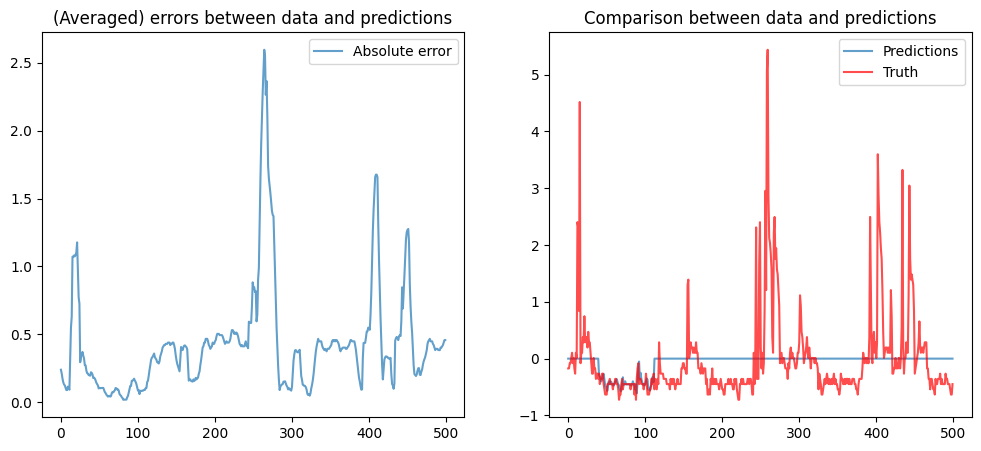

In [5]:
n_samples = 10_000
seq_x = np.array(df["Appliances"][:n_samples].tolist())
seq_y = np.array(df["T_out"][:n_samples].tolist())
res = predict_bivariate(seq_x,seq_y,online=True,plot_tree=True)

Let's do the predictions but with the modified BiVariate Tree (splitting on one variable only at each node instead of the two)

BivariateARTree (offline)
Test MSE: 0.666006
Test MAE: 0.403576
Test MASE: 1.328595


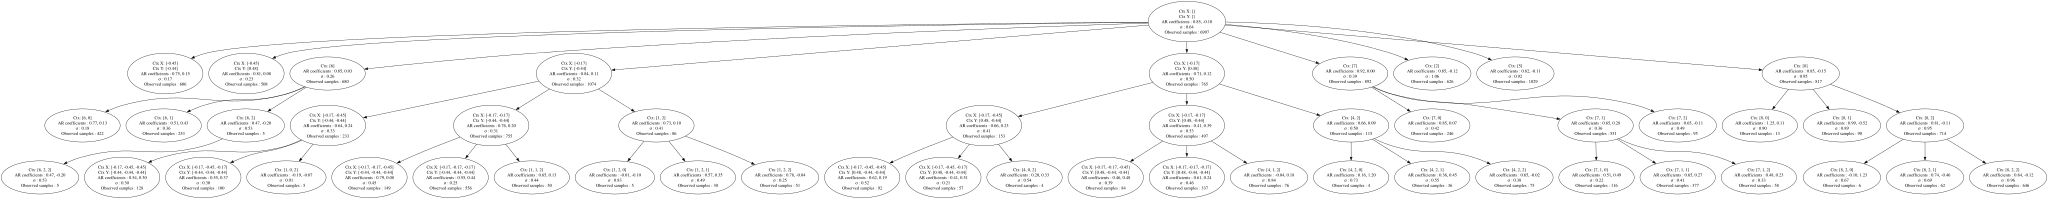

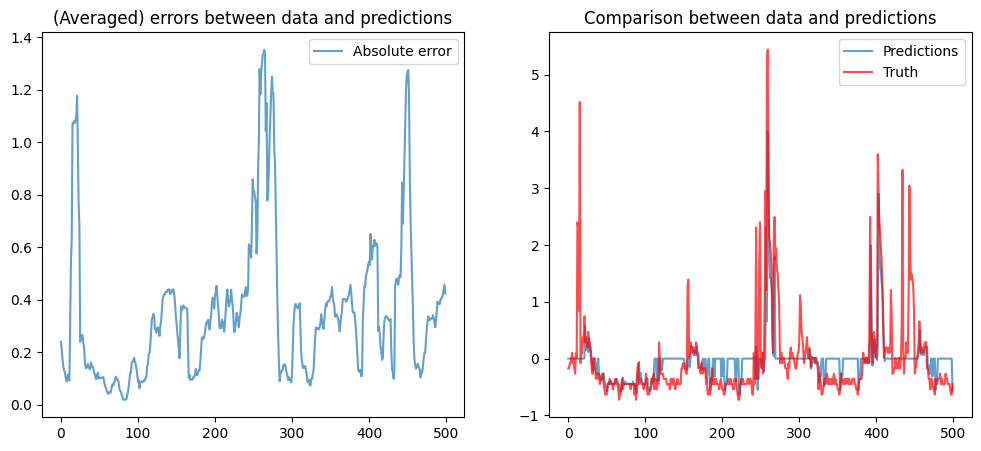

In [6]:
res_bis = predict_bivariate(
    seq_x,
    seq_y,
    online=False,
    use_bis=False,
    quantizer_seq=[0,0,0,1,1,1,1],
    plot_tree=True
)
view_tree(res_bis["tree"].tree, quantizer=res_bis["quantizer"])

BivariateARTreeBis (offline)
Test MSE: 0.439593
Test MAE: 0.315078
Test MASE: 1.037132


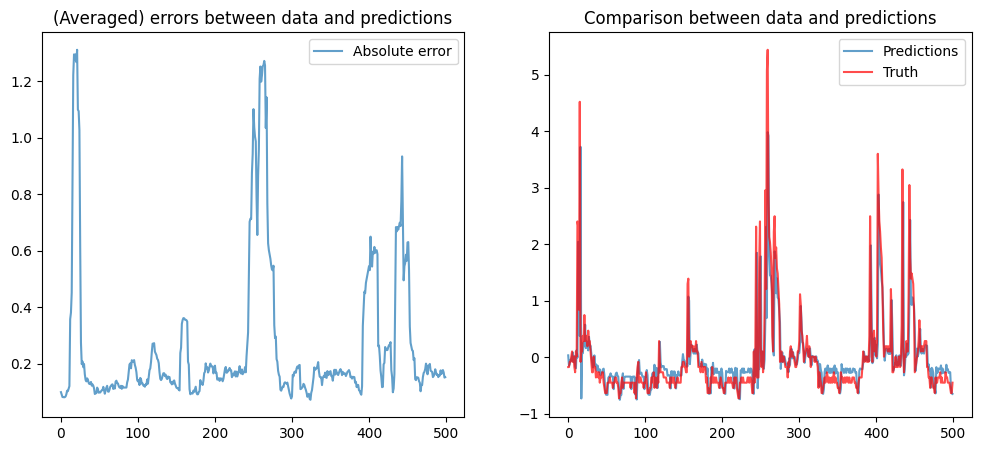

In [7]:
res_bis = predict_bivariate(
    seq_x,
    seq_y,
    online=False,
    use_bis=True,
    quantizer_seq=[1, 0, 1],
)

## 2. Household Electric Power Consumption 

The goal is to predict the Global_active_power, from Voltage. 

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

In [8]:
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",         
    na_values="?",   
    low_memory=False 
)

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[cols] = df[cols].astype(float)
df = df.dropna()
df = df[["datetime", "Global_active_power", "Voltage"]]
df = df.sort_values("datetime").reset_index(drop=True)
df.head()

,datetime,Global_active_power,Voltage
0,2006-12-16 17:24:00,4.216,234.84
1,2006-12-16 17:25:00,5.360,233.63
2,2006-12-16 17:26:00,5.374,233.29
3,2006-12-16 17:27:00,5.388,233.74
4,2006-12-16 17:28:00,3.666,235.68


### Univariate prediction

BivariateARTree (offline)
Test MSE: 0.507980
Test MAE: 0.540573
Test MASE: 2.458831


{'predictions': array([0.        , 0.        , 0.        , ..., 1.91967375, 1.75307661,
        0.64585736], shape=(3000,)),
 'actuals': array([-0.30172449, -0.31665198, -0.24052177, ...,  2.17474658,
         0.84022872,  0.92830093], shape=(3000,)),
 'tree': <ctw.models.BivariateARTree at 0x118329650>,
 'quantizer': <ctw.models.BivariateQuantizer at 0x117bbabd0>,
 'mse': np.float64(0.507980175332033),
 'mae': np.float64(0.540573056132113),
 'mase': np.float64(2.4588311655383106)}

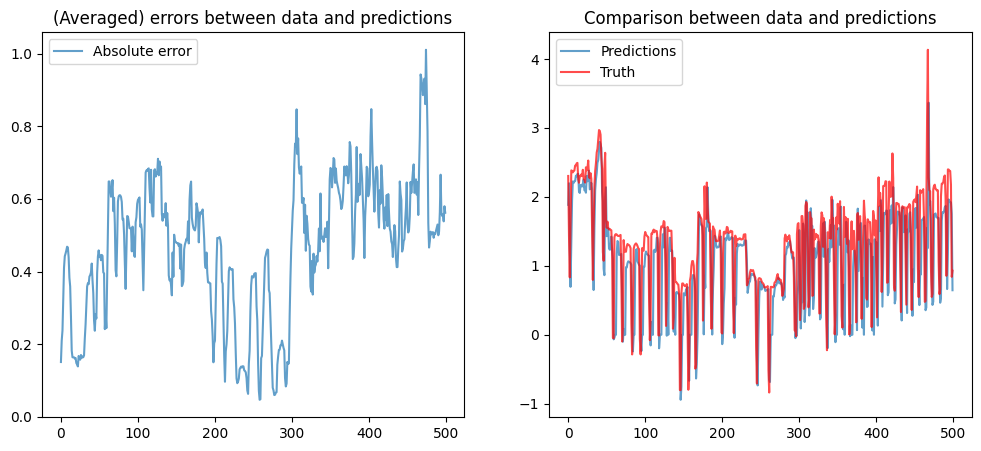

In [9]:
seq_x = np.array(df["Global_active_power"][:n_samples], dtype=float)
seq_y = np.array(df["Voltage"][:n_samples], dtype=float)

predict_bivariate(seq_x,seq_y)

In [10]:
predictions = []
actuals = []

prev_x = x_train[-1]  # dernière valeur vue dans le train

for x_i in seq_x:
    pred = prev_x
    predictions.append(pred)
    actuals.append(x_i)
    prev_x = x_i

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = np.mean(np.abs(predictions - actuals))
mse = np.mean((predictions - actuals) ** 2)

print("Naive baseline - MAE:", mae)
print("Naive baseline - MSE:", mse)

NameError: name 'x_train' is not defined

# Données de santés - vibe-coded

In [77]:
"""
medical_datasets.py
====================
Chargement automatisé de datasets médicaux de séries temporelles pour les
fonctions predict_univariate / predict_bivariate du projet CTW.

Chaque dataset retourne un dict :
    {
        "name":        str,
        "description": str,
        "source":      str,   # URL / référence
        "license":     str,
        "x":           np.ndarray,   # série principale à prédire
        "y":           np.ndarray,   # covariable (None si univarié)
        "x_label":     str,
        "y_label":     str | None,
    }

Datasets disponibles
---------------------
1.  MIT-BIH ECG (MLII + V5)          — wfdb / PhysioNet
2.  BIDMC PPG + respiration           — wfdb / PhysioNet
3.  Santa Fe ECG (compétition)        — wfdb / PhysioNet
4.  UCI Diabetes (glucose + insuline) — ucimlrepo
5.  UCI EEG Eye State                 — URL publique UCI
6.  Apnea-ECG (SpO2 + ECG)           — wfdb / PhysioNet
7.  WESAD (wrist) HR + EDA            — fichier ZIP public GitHub mirror

Usage rapide
-------------
    from medical_datasets import load_dataset, list_datasets

    print(list_datasets())

    ds = load_dataset("mitbih")
    predict_bivariate(ds["x"], ds["y"])

    ds = load_dataset("diabetes")
    predict_univariate(ds["x"])
"""

import io
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

CACHE_DIR = Path(os.environ.get("CTW_DATA_CACHE", "data/medical_cache"))
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path(name: str) -> Path:
    return CACHE_DIR / name


def _download(url: str, dest: Path, chunk_size: int = 1 << 20) -> None:
    """Télécharge `url` vers `dest` avec une barre de progression simple."""
    print(f"  ↓ Téléchargement : {url}")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    with open(dest, "wb") as f:
        total = 0
        for chunk in r.iter_content(chunk_size):
            f.write(chunk)
            total += len(chunk)
    print(f"    → {total / 1e6:.1f} Mo écrits dans {dest}")


# ---------------------------------------------------------------------------
# 1. MIT-BIH Arrhythmia Database
#    Source : PhysioNet  https://physionet.org/content/mitdb/1.0.0/
#    Licence : ODC Attribution License v1.0  (libre)
#    Signaux : MLII (dérivation ECG) + V5 (seconde dérivation)
#    360 Hz, enregistrements de 30 min ; on prend le patient 100 par défaut.
#    Référence : Moody & Mark, Computers in Cardiology 17:185-188 (1990).
# ---------------------------------------------------------------------------

def load_mitbih(record: str = "100", n_samples: int = 10_000) -> dict:
    """
    Charge un enregistrement ECG de la MIT-BIH Arrhythmia Database.

    Source    : https://physionet.org/content/mitdb/1.0.0/
    Licence   : Open Data Commons Attribution License v1.0
    Référence : Moody GB, Mark RG. The MIT-BIH Arrhythmia Database on CD-ROM
                and software for use with it. Computers in Cardiology 17:185-188 (1990).
    """
    try:
        import wfdb  # pip install wfdb
    except ImportError:
        raise ImportError(
            "Le package `wfdb` est requis : pip install wfdb"
        )

    print(f"[MIT-BIH] Chargement du patient {record} via wfdb (PhysioNet)…")
    sig, fields = wfdb.rdsamp(
        record,
        pn_dir="mitdb",
        sampto=n_samples,
    )
    # sig : (n_samples, 2)  colonnes = ['MLII', 'V5']
    x = sig[:, 0].astype(float)   # MLII
    y = sig[:, 1].astype(float)   # V5

    return dict(
        name="MIT-BIH Arrhythmia Database",
        description=(
            f"ECG amblatoire bi-canal du patient {record}. "
            "360 Hz, 11-bit, mélange patients sains et arythmies."
        ),
        source="https://physionet.org/content/mitdb/1.0.0/",
        license="Open Data Commons Attribution License v1.0",
        x=x,
        y=y,
        x_label=f"ECG MLII (patient {record})",
        y_label=f"ECG V5 (patient {record})",
    )


# ---------------------------------------------------------------------------
# 2. BIDMC PPG & Respiration Dataset
#    Source : PhysioNet  https://physionet.org/content/bidmc/1.0.0/
#    Licence : Open Data Commons Attribution License v1.0
#    Signaux : PPG (photopléthysmogramme) + signal respiratoire
#    125 Hz ; 53 sujets adultes en soins intensifs.
#    Référence : Pimentel et al., Annals of Biomedical Engineering (2017).
# ---------------------------------------------------------------------------

def load_bidmc_ppg(subject: int = 1, n_samples: int = 10_000) -> dict:
    """
    Charge PPG + respiration de la BIDMC PPG & Respiration Database.

    Source    : https://physionet.org/content/bidmc/1.0.0/
    Licence   : Open Data Commons Attribution License v1.0
    Référence : Pimentel MA et al. (2017). Toward a Robust Estimation of
                Respiratory Rate from Pulse Oximeters. IEEE TBME 64(8):1914-23.
    """
    try:
        import wfdb
    except ImportError:
        raise ImportError("pip install wfdb")

    rec = f"bidmc{subject:02d}"
    print(f"[BIDMC-PPG] Chargement sujet {subject:02d}…")
    sig, fields = wfdb.rdsamp(rec, pn_dir="bidmc/1.0.0", sampto=n_samples)

    # Colonnes disponibles : II, Pleth, Resp
    col_names = [s.strip() for s in fields["sig_name"]]
    ppg_idx  = col_names.index("Pleth") if "Pleth"  in col_names else 1
    resp_idx = col_names.index("Resp")  if "Resp"   in col_names else 2

    x = sig[:, ppg_idx].astype(float)
    y = sig[:, resp_idx].astype(float)

    return dict(
        name="BIDMC PPG & Respiration Dataset",
        description=(
            f"PPG et signal respiratoire (sujet {subject:02d}), "
            "125 Hz, patients adultes en réanimation."
        ),
        source="https://physionet.org/content/bidmc/1.0.0/",
        license="Open Data Commons Attribution License v1.0",
        x=x,
        y=y,
        x_label="PPG (Pleth)",
        y_label="Respiration",
    )


# ---------------------------------------------------------------------------
# 3. Santa Fe Time Series Competition (ECG)
#    Source : PhysioNet  https://physionet.org/content/santa-fe-ecg/1.0.0/
#    Licence : Open Data Commons Attribution License v1.0
#    Dataset B : ECG humain à 360 Hz – 4 096 échantillons.
#    Classique de la littérature sur la prédiction de séries chaotiques.
#    Référence : Weigend A, Gershenfeld N (eds.), 1993.
# ---------------------------------------------------------------------------

def load_santa_fe(n_samples: int = 4096) -> dict:
    url = "https://physionet.org/files/santa-fe/1.0.0/b1.txt?download="
    cache = _cache_path("santa_fe_b1.txt")
    if not cache.exists():
        _download(url, cache)

    data = np.loadtxt(cache)
    n = min(n_samples, len(data))

    # Colonne 1 = heart rate
    # Colonne 2 = respiration
    # Colonne 3 = blood oxygen
    x = data[:n, 0].astype(float)
    y = data[:n, 1].astype(float)

    return dict(
        name="Santa Fe Time Series Competition Data Set B",
        description=(
            "Série multivariée de sommeil: fréquence cardiaque, respiration "
            "et oxygénation sanguine à 2 Hz."
        ),
        source="https://physionet.org/content/santa-fe/1.0.0/",
        license="Open Data Commons Attribution License v1.0",
        x=x,
        y=y,
        x_label="Heart rate",
        y_label="Respiration",
    )


# ---------------------------------------------------------------------------
# 4. UCI Diabetes Dataset (patients diabétiques type 1, Kahn 1994)
#    Source : UCI ML Repository  https://archive.ics.uci.edu/dataset/34/diabetes
#    Licence : CC BY 4.0
#    Signaux : glycémie (code 48/58/59/60…) + dose insuline régulière (code 33)
#    Les données sont par patient ; on concatène pour former une série.
#    Référence : Kahn M. Diabetes. UCI Machine Learning Repository (1994).
# ---------------------------------------------------------------------------

def load_uci_diabetes(n_samples: int = 10_000) -> dict:
    """
    Série temporelle de glycémies + doses d'insuline rapide (UCI Diabetes).

    Source    : https://archive.ics.uci.edu/dataset/34/diabetes
    Licence   : Creative Commons Attribution 4.0 International (CC BY 4.0)
    Référence : Kahn M. Diabetes [Dataset]. UCI Machine Learning Repository.
                https://doi.org/10.24432/C5T59G
    """
    try:
        from ucimlrepo import fetch_ucirepo  # pip install ucimlrepo
    except ImportError:
        raise ImportError("pip install ucimlrepo")

    print("[UCI Diabetes] Téléchargement via ucimlrepo…")
    ds = fetch_ucirepo(id=34)

    # ucimlrepo peut retourner des StringArray comme noms de colonnes,
    # ce qui casse pd.concat / set_index → on force des str normaux.
    features = ds.data.features.copy()
    targets  = ds.data.targets.copy()
    features = features.astype(object)
    targets  = targets.astype(object)

    features.columns = features.columns.astype(str)
    targets.columns  = targets.columns.astype(str)
    df = pd.concat([features, targets], axis=1)

    # Codes : 48/57-64 = mesure glycémique ; 33 = insuline rapide
    blood_glucose_codes = list(range(48, 65))
    # La colonne "Code" peut être str ou int selon la version d'ucimlrepo
    df["Code"] = pd.to_numeric(df["Code"], errors="coerce")
    glucose_rows = df[df["Code"].isin(blood_glucose_codes)].copy()
    insulin_rows  = df[df["Code"] == 33].copy()

    glucose_vals = glucose_rows["Value"].values.astype(float)
    insulin_vals = insulin_rows["Value"].values.astype(float)

    # Aligner à la même longueur
    min_len = min(len(glucose_vals), len(insulin_vals), n_samples)
    x = glucose_vals[:min_len]
    y = insulin_vals[:min_len]

    return dict(
        name="UCI Diabetes Dataset",
        description=(
            "Glycémies (mg/dL) et doses d'insuline rapide (U) de patients "
            "diabétiques de type 1. Mesures discontinues, concaténées."
        ),
        source="https://archive.ics.uci.edu/dataset/34/diabetes",
        license="CC BY 4.0",
        x=x,
        y=y,
        x_label="Glycémie (mg/dL)",
        y_label="Insuline rapide (U)",
    )


# ---------------------------------------------------------------------------
# 5. UCI EEG Eye State Dataset
#    Source : UCI  https://archive.ics.uci.edu/dataset/264/eeg+eye+state
#    Licence : CC BY 4.0
#    Signaux : 14 canaux EEG (256 Hz) + état oculaire (0=ouvert, 1=fermé)
#    On prend AF3 (x) et F7 (y) pour le bivarié.
#    Référence : Roesler O. EEG Eye State. UCI ML Repository (2013).
# ---------------------------------------------------------------------------

def load_uci_eeg_eyestate(n_samples: int = 10_000) -> dict:
    """
    EEG Eye State — 14 canaux EEG (256 Hz), état oculaire.

    Source    : https://archive.ics.uci.edu/dataset/264/eeg+eye+state
    Licence   : CC BY 4.0
    Référence : Roesler O. EEG Eye State [Dataset].
                UCI Machine Learning Repository (2013).
    """
    url = (
        "https://archive.ics.uci.edu/ml/machine-learning-databases"
        "/00264/EEG%20Eye%20State.arff"
    )
    cache = _cache_path("eeg_eye_state.arff")
    if not cache.exists():
        _download(url, cache)

    # Lire le fichier ARFF manuellement (section @DATA)
    lines = cache.read_text(encoding="utf-8").splitlines()
    data_start = next(
        i for i, l in enumerate(lines) if l.strip().upper() == "@DATA"
    ) + 1
    data_lines = [l for l in lines[data_start:] if l.strip() and not l.startswith("%")]
    arr = np.array(
        [[float(v) for v in l.split(",")] for l in data_lines]
    )

    # Colonnes : AF3 F7 F8 T4 T8 T6 T4 ... eyeDetection
    n = min(n_samples, len(arr))
    x = arr[:n, 0]   # AF3
    y = arr[:n, 1]   # F7

    return dict(
        name="UCI EEG Eye State",
        description=(
            "14 canaux EEG à 256 Hz lors d'ouverture/fermeture des yeux. "
            "Enregistrement continu d'une session unique."
        ),
        source="https://archive.ics.uci.edu/dataset/264/eeg+eye+state",
        license="CC BY 4.0",
        x=x,
        y=y,
        x_label="EEG AF3 (µV)",
        y_label="EEG F7 (µV)",
    )


# ---------------------------------------------------------------------------
# 6. Apnea-ECG Database
#    Source : PhysioNet  https://physionet.org/content/apnea-ecg/1.0.0/
#    Licence : Open Data Commons Attribution License v1.0
#    Signaux : ECG lead II + annotations apnée (par minute)
#    On charge l'ECG brut et le signal de SpO2 reconstitué quand dispo.
#    Référence : Penzel T et al., Computers in Cardiology (2000).
# ---------------------------------------------------------------------------

def load_apnea_ecg(record: str = "a01", n_samples: int = 10_000) -> dict:
    """
    ECG + annotation apnée (Apnea-ECG Database).

    Source    : https://physionet.org/content/apnea-ecg/1.0.0/
    Licence   : Open Data Commons Attribution License v1.0
    Référence : Penzel T, Moody GB, Mark RG, Goldberger AL, Peter JH.
                The Apnea-ECG Database. Computers in Cardiology 27:255-258 (2000).
    """
    try:
        import wfdb
    except ImportError:
        raise ImportError("pip install wfdb")

    print(f"[Apnea-ECG] Chargement enregistrement {record}…")
    sig, fields = wfdb.rdsamp(record, pn_dir="apnea-ecg", sampto=n_samples)

    # 1 canal ECG, 100 Hz
    x = sig[:, 0].astype(float)

    # Annotations apnée (une étiquette par minute) → interpolées sur l'ECG
    try:
        ann = wfdb.rdann(record, "apn", pn_dir="apnea-ecg")
        apnea_labels = np.zeros(len(x))
        fs = fields["fs"]
        for idx, sym in zip(ann.sample, ann.symbol):
            if idx < len(apnea_labels):
                apnea_labels[idx] = 1.0 if sym == "A" else 0.0
        y = apnea_labels
        y_label = "Apnée (1=présente, 0=absente)"
    except Exception:
        y = None
        y_label = None

    return dict(
        name="Apnea-ECG Database",
        description=(
            f"ECG (100 Hz, enregistrement {record}) avec annotations "
            "apnée du sommeil par minute."
        ),
        source="https://physionet.org/content/apnea-ecg/1.0.0/",
        license="Open Data Commons Attribution License v1.0",
        x=x,
        y=y,
        x_label="ECG (mV)",
        y_label=y_label,
    )


# ---------------------------------------------------------------------------
# 7. UCI Cuff-Less Blood Pressure (PPG + ECG → pression artérielle)
#    Source : UCI  https://archive.ics.uci.edu/dataset/340
#    Licence : CC BY 4.0
#    Signaux : PPG + ECG, pression artérielle systolique et diastolique
#    Format : fichiers Matlab (.mat) → on utilise scipy
#    Référence : Kachuee M et al. (2015). Cuff-Less Blood Pressure Estimation.
# ---------------------------------------------------------------------------

def load_cuffless_bp(subject_idx: int = 0, n_samples: int = 10_000) -> dict:
    """
    PPG et pression artérielle (UCI Cuff-Less Blood Pressure).

    Source    : https://archive.ics.uci.edu/dataset/340/
                cuff+less+blood+pressure+estimation
    Licence   : CC BY 4.0
    Référence : Kachuee M, Kiani MM, Mohammadzade H, Shabany M. (2015).
                Cuff-Less High-Accuracy Calibration-Free Blood Pressure
                Estimation Using Pulse Transit Time. IEEE ISCAS.
    """
    try:
        from scipy.io import loadmat  # pip install scipy
    except ImportError:
        raise ImportError("pip install scipy")

    url = (
        "https://archive.ics.uci.edu/ml/machine-learning-databases"
        "/00340/data.zip"
    )
    zip_cache = _cache_path("cuffless_bp.zip")
    mat_cache  = _cache_path("cuffless_bp_part1.mat")

    if not mat_cache.exists():
        if not zip_cache.exists():
            _download(url, zip_cache)
        print("[Cuffless-BP] Extraction…")
        with zipfile.ZipFile(zip_cache) as zf:
            # Contient Part_1.mat … Part_n.mat
            names = [n for n in zf.namelist() if n.endswith(".mat")]
            names.sort()
            with zf.open(names[0]) as src, open(mat_cache, "wb") as dst:
                dst.write(src.read())

    mat = loadmat(str(mat_cache))
    # Structure : mat["Part_1"] → (n_subjects, 1) de cell arrays
    # Chaque cell : (3, T) → lignes = [PPG, ECG, BP_sys, BP_dias]
    part = mat[[k for k in mat if not k.startswith("_")][0]]
    cell = part[subject_idx, 0]  # (3 ou 4, T)
    ppg = cell[0].astype(float).ravel()
    bp  = cell[2].astype(float).ravel() if cell.shape[0] > 2 else cell[1].astype(float).ravel()

    n = min(n_samples, len(ppg), len(bp))
    x, y = ppg[:n], bp[:n]

    return dict(
        name="UCI Cuff-Less Blood Pressure Estimation",
        description=(
            "PPG et pression artérielle systolique estimée, "
            "signaux physiologiques 125 Hz."
        ),
        source=(
            "https://archive.ics.uci.edu/dataset/340/"
            "cuff+less+blood+pressure+estimation"
        ),
        license="CC BY 4.0",
        x=x,
        y=y,
        x_label="PPG",
        y_label="Pression artérielle systolique (mmHg)",
    )


# ---------------------------------------------------------------------------
# Registre & fonctions publiques
# ---------------------------------------------------------------------------

_REGISTRY = {
    "mitbih": (
        load_mitbih,
        "ECG bi-canal (MLII + V5), MIT-BIH, 360 Hz",
    ),
    "bidmc_ppg": (
        load_bidmc_ppg,
        "PPG + respiration, BIDMC, 125 Hz",
    ),
    "apnea_ecg": (
        load_apnea_ecg,
        "ECG + annotations apnée, 100 Hz",
    ),
}


def list_datasets() -> str:
    lines = ["Datasets médicaux disponibles :\n"]
    for key, (_, desc) in _REGISTRY.items():
        lines.append(f"  {key:<14} – {desc}")
    return "\n".join(lines)


def load_dataset(name: str, n_samples: int = 10_000, **kwargs) -> dict:
    """
    Charge un dataset par son identifiant.

    Paramètres
    ----------
    name      : clé dans list_datasets()
    n_samples : nombre d'échantillons à extraire
    **kwargs  : arguments spécifiques au loader
                 ex. record="101" pour mitbih
                 ex. subject=2 pour bidmc_ppg
                 ex. record="a02" pour apnea_ecg
    """
    if name not in _REGISTRY:
        raise ValueError(
            f"Dataset inconnu : '{name}'. "
            f"Disponibles : {list(_REGISTRY.keys())}"
        )
    loader, _ = _REGISTRY[name]
    return loader(n_samples=n_samples, **kwargs)

# ---------------------------------------------------------------------------
# Intégration directe avec predict_univariate / predict_bivariate
# ---------------------------------------------------------------------------

def run_all_benchmarks(
    n_samples: int = 8_000,
    online: bool = False,
    datasets: list | None = None,
) -> dict:
    import matplotlib.pyplot as plt

    try:
        from __main__ import predict_univariate, predict_bivariate
    except ImportError:
        raise RuntimeError(
            "Les fonctions predict_univariate et predict_bivariate doivent "
            "être définies dans __main__ ou importées avant d'appeler "
            "run_all_benchmarks()."
        )

    to_run = datasets or ["mitbih", "bidmc_ppg", "apnea_ecg"]
    all_results = {}

    for name in to_run:
        print(f"\n{'='*60}")
        print(f"Dataset : {name}")
        print('='*60)

        try:
            ds = load_dataset(name, n_samples=n_samples)

            print(f"  Source  : {ds['source']}")
            print(f"  Licence : {ds['license']}")
            print(f"  x       : {ds['x_label']}  ({len(ds['x'])} pts)")

            if ds["y"] is not None:
                print(f"  y       : {ds['y_label']}  ({len(ds['y'])} pts)")
                result = predict_bivariate(
                    ds["x"],
                    ds["y"],
                    online=online,
                    plot_tree=False,
                )
            else:
                result = predict_univariate(
                    ds["x"],
                    online=online,
                    plot_tree=False,
                )

            plt.suptitle(f"{ds['name']}", y=1.02)
            plt.tight_layout()
            plt.show()

            all_results[name] = result

        except Exception as e:
            print(f"  ⚠ Erreur lors du chargement/prédiction : {e}")
            all_results[name] = {"error": str(e)}

    print(f"\n{'='*60}")
    print("Résumé des performances")
    print('='*60)

    for name, res in all_results.items():
        if isinstance(res, dict) and "error" not in res:
            mse = res.get("mse", float("nan"))
            mae = res.get("mae", float("nan"))
            mase = res.get("mase", float("nan"))
            print(f"  {name:<14}  MSE={mse:.4f}  MAE={mae:.4f}  MASE={mase:.4f}")
        else:
            err = res.get("error", "?") if isinstance(res, dict) else str(res)
            print(f"  {name:<14}  ERREUR : {err}")

    return all_results

def benchmark_methods(
    x,
    y=None,
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=100,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
):
    if verbose:
        print("=" * 70)
        print("Début du benchmark")
        print("=" * 70)

    # ------------------------------------------------------
    # Standardisation train-based
    # ------------------------------------------------------
    x_train, x_test, mu_x, sigma_x, split_idx = standardize_train_test(
        x, split_ratio=train_ratio
    )
    x_std = np.concatenate([x_train, x_test])

    if y is not None:
        y_train, y_test, mu_y, sigma_y, _ = standardize_train_test(
            y, split_ratio=train_ratio
        )
        y_std = np.concatenate([y_train, y_test])
    else:
        y_train, y_test, y_std = None, None, None

    if verbose:
        print(f"[DATA] Train={len(x_train)} | Test={len(x_test)}")

    results = {}

    # ------------------------------------------------------
    # Baseline lag1 - 1 step
    # ------------------------------------------------------
    if verbose:
        print("[lag1] Évaluation 1-step...")

    pred_lag1 = lag1_predictions_1step(x_train, x_test)
    results["lag1"] = {
        "mse_1step": mse(x_test, pred_lag1),
        "mae_1step": mae(x_test, pred_lag1),
    }

    if verbose:
        print(
            f"[lag1] mse_1step={results['lag1']['mse_1step']:.6f} | "
            f"mae_1step={results['lag1']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # AR - fit train only
    # ------------------------------------------------------
    if verbose:
        print("[AR] Fit sur le train uniquement...")

    intercept, coefs = fit_ar_ols(x_train, p=ar_order, verbose=verbose)

    pred_ar = ar_predictions_1step(x_train, x_test, p=ar_order)
    results["ar"] = {
        "mse_1step": mse(x_test, pred_ar),
        "mae_1step": mae(x_test, pred_ar),
    }

    if verbose:
        print(
            f"[AR] mse_1step={results['ar']['mse_1step']:.6f} | "
            f"mae_1step={results['ar']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # Univariate CTW - fit train only
    # ------------------------------------------------------
    if verbose:
        print("[Univariate CTW] Fit sur le train uniquement...")

    uni_tree, uni_quantizer = fit_univariate_tree(
        x_train=x_train,
        order=2,
        max_depth=2,
        n_passes=4,
        verbose=verbose,
    )

    pred_uni = []
    full = np.concatenate([x_train, x_test])
    for t in range(len(x_train), len(full)):
        history = full[t - 2:t]
        pred_uni.append(uni_tree.predict(history))

    pred_uni = np.asarray(pred_uni, dtype=float)
    results["univariate"] = {
        "mse_1step": mse(x_test, pred_uni),
        "mae_1step": mae(x_test, pred_uni),
    }

    if verbose:
        print(
            f"[Univariate CTW] mse_1step={results['univariate']['mse_1step']:.6f} | "
            f"mae_1step={results['univariate']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # Bivariate CTW - fit train only
    # ------------------------------------------------------
    if y is not None:
        if verbose:
            print("[Bivariate CTW] Fit sur le train uniquement...")

        bi_tree, bi_quantizer = fit_bivariate_tree(
            x_train=x_train,
            y_train=y_train,
            order=2,
            max_depth=3,
            verbose=verbose,
        )

        pred_bi = []
        x_seen = list(x_train)
        y_seen = list(y_train)
        hist_len = max(3, 2)

        for x_i, y_i in zip(x_test, y_test):
            history = np.array([
                x_seen[-hist_len:],
                y_seen[-hist_len:],
            ], dtype=float)

            pred = bi_tree.predict(history)
            pred_bi.append(pred)

            x_seen.append(x_i)
            y_seen.append(y_i)

        pred_bi = np.asarray(pred_bi, dtype=float)
        results["bivariate"] = {
            "mse_1step": mse(x_test, pred_bi),
            "mae_1step": mae(x_test, pred_bi),
        }

        if verbose:
            print(
                f"[Bivariate CTW] mse_1step={results['bivariate']['mse_1step']:.6f} | "
                f"mae_1step={results['bivariate']['mae_1step']:.6f}"
            )

    # ------------------------------------------------------
    # k-step
    # ------------------------------------------------------
    rng = np.random.default_rng(seed)

    for k in k_list:
        if verbose:
            print("-" * 70)
            print(f"[k-step] Évaluation horizon k={k}")

        candidate_origins = np.arange(split_idx, len(x_std) - k)
        n_use = min(n_random_origins, len(candidate_origins))
        origins = rng.choice(candidate_origins, size=n_use, replace=False)

        method_mses = {
            "lag1": [],
            "ar": [],
            "univariate": [],
            "bivariate": [],
        }
        method_maes = {
            "lag1": [],
            "ar": [],
            "univariate": [],
            "bivariate": [],
        }

        iterator = origins
        if verbose:
            from tqdm.auto import tqdm
            iterator = tqdm(origins, desc=f"[Benchmark] Origines k={k}")

        for t in iterator:
            history_x = x_std[:t]
            true_future_x = x_std[t:t + k]

            # lag1
            pred_lag1_k = lag1_forecast_k(history_x, k)
            method_mses["lag1"].append(mse(true_future_x, pred_lag1_k))
            method_maes["lag1"].append(mae(true_future_x, pred_lag1_k))

            # AR
            pred_ar_k = ar_forecast_k(history_x, k, intercept, coefs)
            method_mses["ar"].append(mse(true_future_x, pred_ar_k))
            method_maes["ar"].append(mae(true_future_x, pred_ar_k))

            # Univariate CTW (sans refit)
            pred_uni_k = univariate_forecast_k_with_fitted_tree(
                tree=uni_tree,
                history_x=history_x,
                k=k,
                order=2,
            )
            method_mses["univariate"].append(mse(true_future_x, pred_uni_k))
            method_maes["univariate"].append(mae(true_future_x, pred_uni_k))

            # Bivariate CTW (sans refit)
            if y_std is not None:
                history_y = y_std[:t]
                future_y = y_std[t:t + k]

                pred_bi_k = bivariate_forecast_k_with_fitted_tree(
                    tree=bi_tree,
                    history_x=history_x,
                    history_y=history_y,
                    k=k,
                    future_y=future_y,
                    use_future_y=use_future_y_bivariate,
                    order=2,
                    max_depth=3,
                )
                method_mses["bivariate"].append(mse(true_future_x, pred_bi_k))
                method_maes["bivariate"].append(mae(true_future_x, pred_bi_k))

        for method in ["lag1", "ar", "univariate", "bivariate"]:
            if len(method_mses[method]) > 0:
                results[method][f"mse_k{k}"] = float(np.mean(method_mses[method]))
                results[method][f"mae_k{k}"] = float(np.mean(method_maes[method]))

                if verbose:
                    print(
                        f"[{method}] k={k} | "
                        f"MSE={results[method][f'mse_k{k}']:.6f} | "
                        f"MAE={results[method][f'mae_k{k}']:.6f}"
                    )

    if verbose:
        print("=" * 70)
        print("Benchmark terminé")
        print("=" * 70)

    return results

In [72]:
ds = load_dataset("mitbih", n_samples=8000)

scores = benchmark_methods(
    x=ds["x"],
    y=ds["y"],
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=50,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
)

pd.DataFrame(scores).T

[MIT-BIH] Chargement du patient 100 via wfdb (PhysioNet)…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.100979 | mae_1step=0.119317
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.80546055 -0.88944914]
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.80546055 -0.88944914]
[AR] mse_1step=0.019845 | mae_1step=0.091185
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train: 100%|██████████| 4/4 [00:02<00:00,  1.65it/s]


[Univariate CTW] Fit terminé.
[Univariate CTW] mse_1step=0.024020 | mae_1step=0.086850
[Bivariate CTW] Fit sur le train uniquement...
[Bivariate CTW] Initialisation du modèle (order=2, max_depth=3)


[Bivariate CTW] Observations train: 100%|██████████| 5600/5600 [00:00<00:00, 5846.90it/s]


[Bivariate CTW] Fit terminé.
[Bivariate CTW] mse_1step=0.030856 | mae_1step=0.083602
----------------------------------------------------------------------
[k-step] Évaluation horizon k=3


...

[Benchmark] Origines k=5: 100%|██████████| 50/50 [00:00<00:00, 983.21it/s]


[lag1] k=5 | MSE=0.856994 | MAE=0.249120
[ar] k=5 | MSE=0.170700 | MAE=0.255355
[univariate] k=5 | MSE=0.093656 | MAE=0.167916
[bivariate] k=5 | MSE=0.109463 | MAE=0.160434
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10: 100%|██████████| 50/50 [00:00<00:00, 727.95it/s]

[lag1] k=10 | MSE=2.550021 | MAE=0.526466
[ar] k=10 | MSE=0.993591 | MAE=0.496837
[univariate] k=10 | MSE=1.033967 | MAE=0.373407
[bivariate] k=10 | MSE=0.749128 | MAE=0.348333
Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.100979,0.119317,0.377749,0.181093,0.856994,0.249120,2.550021,0.526466
ar,0.019845,0.091185,0.203529,0.212854,0.170700,0.255355,0.993591,0.496837
univariate,0.024020,0.086850,0.151069,0.176727,0.093656,0.167916,1.033967,0.373407
bivariate,0.030856,0.083602,0.111596,0.147579,0.109463,0.160434,0.749128,0.348333


In [78]:
import numpy as np
import matplotlib.pyplot as plt


def plot_prediction_single_with_regimes(
    actuals,
    predictions,
    title="",
    xlabel="Time",
    ylabel="x",
    regime_ids=None,
    data_to_plot=500,
):
    actuals = np.asarray(actuals, dtype=float)
    predictions = np.asarray(predictions, dtype=float)

    n = min(len(actuals), len(predictions))
    actuals = actuals[:n]
    predictions = predictions[:n]

    s = max(0, n - data_to_plot)
    x = np.arange(s, n)

    fig, ax = plt.subplots(figsize=(12, 5))

    if regime_ids is not None:
        regime_ids = np.asarray(regime_ids)
        regime_ids = regime_ids[:n]
        add_regime_background(ax, regime_ids[s:n], x_offset=s, alpha=0.28)

    ax.plot(x, predictions[s:n], color="black", linewidth=1.5, label="Prediction")
    ax.plot(x, actuals[s:n], color="red", linewidth=1.5, alpha=0.8, label="Truth")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_prediction_bivariate_with_regimes(
    actuals,
    predictions,
    y_series,
    regime_ids=None,
    title="",
    title2="Auxiliary series y",
    xlabel="Time",
    ylabel="x",
    ylabel2="y",
    data_to_plot=500,
):
    actuals = np.asarray(actuals, dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    y_series = np.asarray(y_series, dtype=float)

    n = min(len(actuals), len(predictions), len(y_series))
    actuals = actuals[:n]
    predictions = predictions[:n]
    y_series = y_series[:n]

    s = max(0, n - data_to_plot)
    x = np.arange(s, n)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    if regime_ids is not None:
        regime_ids = np.asarray(regime_ids)
        regime_ids = regime_ids[:n]
        add_regime_background(ax1, regime_ids[s:n], x_offset=s, alpha=0.28)

    ax1.plot(x, predictions[s:n], color="black", linewidth=1.5, label="Prediction")
    ax1.plot(x, actuals[s:n], color="red", linewidth=1.5, alpha=0.8, label="Truth")
    ax1.set_title(title)
    ax1.set_ylabel(ylabel)
    ax1.grid(False)
    ax1.legend()

    ax2.plot(x, y_series[s:n], color="black", linewidth=1.5)
    ax2.set_title(title2)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel2)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

def benchmark_methods(
    x,
    y=None,
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=100,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
    make_plots=False,
    n_samples_plot=500,
    plot_title_prefix="",
):
    if verbose:
        print("=" * 70)
        print("Début du benchmark")
        print("=" * 70)

    # ------------------------------------------------------
    # Standardisation train-based
    # ------------------------------------------------------
    x_train, x_test, mu_x, sigma_x, split_idx = standardize_train_test(
        x, split_ratio=train_ratio
    )
    x_std = np.concatenate([x_train, x_test])

    if y is not None:
        y_train, y_test, mu_y, sigma_y, _ = standardize_train_test(
            y, split_ratio=train_ratio
        )
        y_std = np.concatenate([y_train, y_test])
    else:
        y_train, y_test, y_std = None, None, None

    if verbose:
        print(f"[DATA] Train={len(x_train)} | Test={len(x_test)}")

    results = {}
    one_step_predictions = {}

    # ------------------------------------------------------
    # Baseline lag1 - 1 step
    # ------------------------------------------------------
    if verbose:
        print("[lag1] Évaluation 1-step...")

    pred_lag1 = lag1_predictions_1step(x_train, x_test)
    one_step_predictions["lag1"] = pred_lag1

    results["lag1"] = {
        "mse_1step": mse(x_test, pred_lag1),
        "mae_1step": mae(x_test, pred_lag1),
    }

    if verbose:
        print(
            f"[lag1] mse_1step={results['lag1']['mse_1step']:.6f} | "
            f"mae_1step={results['lag1']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # AR - fit train only
    # ------------------------------------------------------
    if verbose:
        print("[AR] Fit sur le train uniquement...")

    intercept, coefs = fit_ar_ols(x_train, p=ar_order, verbose=verbose)

    pred_ar = ar_predictions_1step(x_train, x_test, p=ar_order)
    one_step_predictions["ar"] = pred_ar

    results["ar"] = {
        "mse_1step": mse(x_test, pred_ar),
        "mae_1step": mae(x_test, pred_ar),
    }

    if verbose:
        print(
            f"[AR] mse_1step={results['ar']['mse_1step']:.6f} | "
            f"mae_1step={results['ar']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # Univariate CTW - fit train only
    # ------------------------------------------------------
    if verbose:
        print("[Univariate CTW] Fit sur le train uniquement...")

    uni_tree, uni_quantizer = fit_univariate_tree(
        x_train=x_train,
        order=2,
        max_depth=2,
        n_passes=4,
        verbose=verbose,
    )

    pred_uni = []
    full = np.concatenate([x_train, x_test])
    for t in range(len(x_train), len(full)):
        history = full[t - 2:t]
        pred_uni.append(uni_tree.predict(history))

    pred_uni = np.asarray(pred_uni, dtype=float)
    one_step_predictions["univariate"] = pred_uni

    results["univariate"] = {
        "mse_1step": mse(x_test, pred_uni),
        "mae_1step": mae(x_test, pred_uni),
    }

    if verbose:
        print(
            f"[Univariate CTW] mse_1step={results['univariate']['mse_1step']:.6f} | "
            f"mae_1step={results['univariate']['mae_1step']:.6f}"
        )

    # ------------------------------------------------------
    # Bivariate CTW - fit train only
    # ------------------------------------------------------
    bi_tree = None
    bi_quantizer = None

    if y is not None:
        if verbose:
            print("[Bivariate CTW] Fit sur le train uniquement...")

        bi_tree, bi_quantizer = fit_bivariate_tree(
            x_train=x_train,
            y_train=y_train,
            order=2,
            max_depth=3,
            verbose=verbose,
        )

        pred_bi = []
        x_seen = list(x_train)
        y_seen = list(y_train)
        hist_len = max(3, 2)

        for x_i, y_i in zip(x_test, y_test):
            history = np.array([
                x_seen[-hist_len:],
                y_seen[-hist_len:],
            ], dtype=float)

            pred = bi_tree.predict(history)
            pred_bi.append(pred)

            x_seen.append(x_i)
            y_seen.append(y_i)

        pred_bi = np.asarray(pred_bi, dtype=float)
        one_step_predictions["bivariate"] = pred_bi

        results["bivariate"] = {
            "mse_1step": mse(x_test, pred_bi),
            "mae_1step": mae(x_test, pred_bi),
        }

        if verbose:
            print(
                f"[Bivariate CTW] mse_1step={results['bivariate']['mse_1step']:.6f} | "
                f"mae_1step={results['bivariate']['mae_1step']:.6f}"
            )

    # ------------------------------------------------------
    # k-step
    # ------------------------------------------------------
    rng = np.random.default_rng(seed)

    for k in k_list:
        if verbose:
            print("-" * 70)
            print(f"[k-step] Évaluation horizon k={k}")

        candidate_origins = np.arange(split_idx, len(x_std) - k)
        n_use = min(n_random_origins, len(candidate_origins))
        origins = rng.choice(candidate_origins, size=n_use, replace=False)

        method_mses = {
            "lag1": [],
            "ar": [],
            "univariate": [],
            "bivariate": [],
        }
        method_maes = {
            "lag1": [],
            "ar": [],
            "univariate": [],
            "bivariate": [],
        }

        iterator = origins
        if verbose:
            from tqdm.auto import tqdm
            iterator = tqdm(origins, desc=f"[Benchmark] Origines k={k}")

        for t in iterator:
            history_x = x_std[:t]
            true_future_x = x_std[t:t + k]

            pred_lag1_k = lag1_forecast_k(history_x, k)
            method_mses["lag1"].append(mse(true_future_x, pred_lag1_k))
            method_maes["lag1"].append(mae(true_future_x, pred_lag1_k))

            pred_ar_k = ar_forecast_k(history_x, k, intercept, coefs)
            method_mses["ar"].append(mse(true_future_x, pred_ar_k))
            method_maes["ar"].append(mae(true_future_x, pred_ar_k))

            pred_uni_k = univariate_forecast_k_with_fitted_tree(
                tree=uni_tree,
                history_x=history_x,
                k=k,
                order=2,
            )
            method_mses["univariate"].append(mse(true_future_x, pred_uni_k))
            method_maes["univariate"].append(mae(true_future_x, pred_uni_k))

            if y_std is not None:
                history_y = y_std[:t]
                future_y = y_std[t:t + k]

                pred_bi_k = bivariate_forecast_k_with_fitted_tree(
                    tree=bi_tree,
                    history_x=history_x,
                    history_y=history_y,
                    k=k,
                    future_y=future_y,
                    use_future_y=use_future_y_bivariate,
                    order=2,
                    max_depth=3,
                )
                method_mses["bivariate"].append(mse(true_future_x, pred_bi_k))
                method_maes["bivariate"].append(mae(true_future_x, pred_bi_k))

        for method in ["lag1", "ar", "univariate", "bivariate"]:
            if len(method_mses[method]) > 0:
                results[method][f"mse_k{k}"] = float(np.mean(method_mses[method]))
                results[method][f"mae_k{k}"] = float(np.mean(method_maes[method]))

                if verbose:
                    print(
                        f"[{method}] k={k} | "
                        f"MSE={results[method][f'mse_k{k}']:.6f} | "
                        f"MAE={results[method][f'mae_k{k}']:.6f}"
                    )

    # ------------------------------------------------------
    # Plots 1-step avec régimes effectivement utilisés
    # ------------------------------------------------------
    plot_artifacts = {}

    if make_plots:
        title_prefix = f"{plot_title_prefix} — " if plot_title_prefix else ""

        # lag1
        plot_prediction_single_with_regimes(
            actuals=x_test,
            predictions=one_step_predictions["lag1"],
            regime_ids=None,
            title=f"{title_prefix}Lag-1 baseline",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

        # AR
        plot_prediction_single_with_regimes(
            actuals=x_test,
            predictions=one_step_predictions["ar"],
            regime_ids=None,
            title=f"{title_prefix}AR({ar_order}) baseline",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

        # Univariate CTW + vrais contextes utilisés
        uni_trace = trace_univariate_regimes(
            seq_x=x,
            split=train_ratio,
            online=False,
        )
        uni_regime_ids, uni_context_map = context_to_regime_ids(uni_trace["contexts"])

        plot_prediction_single_with_regimes(
            actuals=uni_trace["actuals"],
            predictions=one_step_predictions["univariate"],
            regime_ids=uni_regime_ids,
            title=f"{title_prefix}Univariate CTW",
            ylabel="x",
            data_to_plot=n_samples_plot,
        )

        plot_artifacts["univariate"] = {
            "trace": uni_trace,
            "regime_ids": uni_regime_ids,
            "context_map": uni_context_map,
        }

        # Bivariate CTW + vrais contextes utilisés
        if y is not None and "bivariate" in one_step_predictions:
            bi_trace = trace_bivariate_regimes(
                seq_x=x,
                seq_y=y,
                split=train_ratio,
                online=False,
            )
            bi_regime_ids, bi_context_map = context_to_regime_ids(bi_trace["contexts"])

            plot_prediction_bivariate_with_regimes(
                actuals=bi_trace["actuals"],
                predictions=one_step_predictions["bivariate"],
                y_series=np.asarray(y)[split_idx:],
                regime_ids=bi_regime_ids,
                title=f"{title_prefix}Bivariate CTW",
                title2=f"{title_prefix}Auxiliary series y",
                ylabel="x",
                ylabel2="y",
                data_to_plot=n_samples_plot,
            )

            plot_artifacts["bivariate"] = {
                "trace": bi_trace,
                "regime_ids": bi_regime_ids,
                "context_map": bi_context_map,
            }

    if verbose:
        print("=" * 70)
        print("Benchmark terminé")
        print("=" * 70)

    return {
        "scores": results,
        "predictions_1step": one_step_predictions,
        "plot_artifacts": plot_artifacts,
    }
    

[MIT-BIH] Chargement du patient 100 via wfdb (PhysioNet)…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.100979 | mae_1step=0.119317
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.80546055 -0.88944914]
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.80546055 -0.88944914]
[AR] mse_1step=0.019845 | mae_1step=0.091185
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train: 100%|██████████| 4/4 [00:02<00:00,  1.68it/s]


[Univariate CTW] Fit terminé.
[Univariate CTW] mse_1step=0.024020 | mae_1step=0.086850
[Bivariate CTW] Fit sur le train uniquement...
[Bivariate CTW] Initialisation du modèle (order=2, max_depth=3)


[Bivariate CTW] Observations train: 100%|██████████| 5600/5600 [00:00<00:00, 6091.23it/s]


[Bivariate CTW] Fit terminé.
[Bivariate CTW] mse_1step=0.030856 | mae_1step=0.083602
----------------------------------------------------------------------
[k-step] Évaluation horizon k=3


...

[lag1] k=3 | MSE=0.377749 | MAE=0.181093
[ar] k=3 | MSE=0.203529 | MAE=0.212854
[univariate] k=3 | MSE=0.151069 | MAE=0.176727
[bivariate] k=3 | MSE=0.111596 | MAE=0.147579
----------------------------------------------------------------------
[k-step] Évaluation horizon k=5


[Benchmark] Origines k=5: 100%|██████████| 50/50 [00:00<00:00, 1069.51it/s]


[lag1] k=5 | MSE=0.856994 | MAE=0.249120
[ar] k=5 | MSE=0.170700 | MAE=0.255355
[univariate] k=5 | MSE=0.093656 | MAE=0.167916
[bivariate] k=5 | MSE=0.109463 | MAE=0.160434
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10: 100%|██████████| 50/50 [00:00<00:00, 522.41it/s]


[lag1] k=10 | MSE=2.550021 | MAE=0.526466
[ar] k=10 | MSE=0.993591 | MAE=0.496837
[univariate] k=10 | MSE=1.033967 | MAE=0.373407
[bivariate] k=10 | MSE=0.749128 | MAE=0.348333


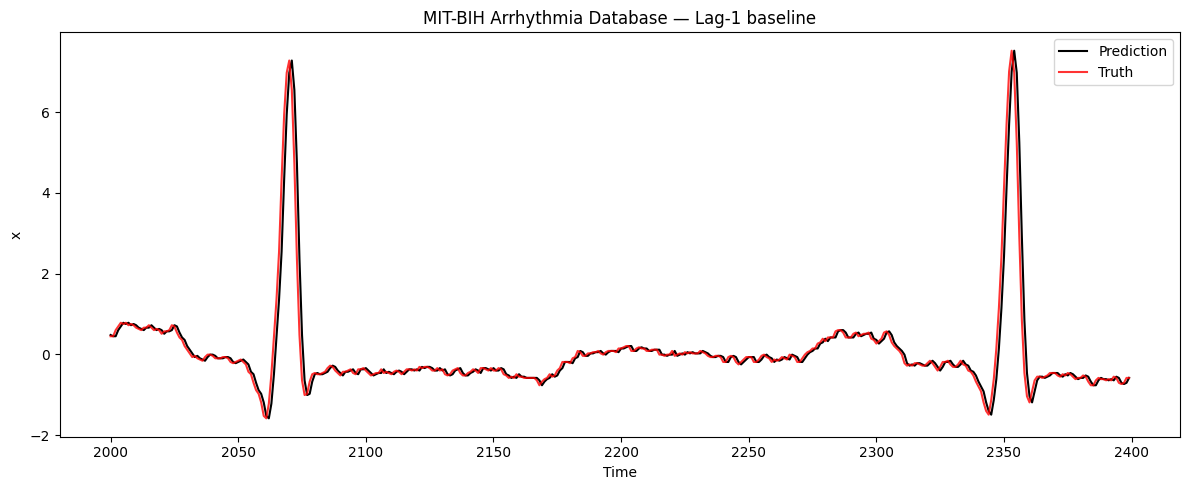

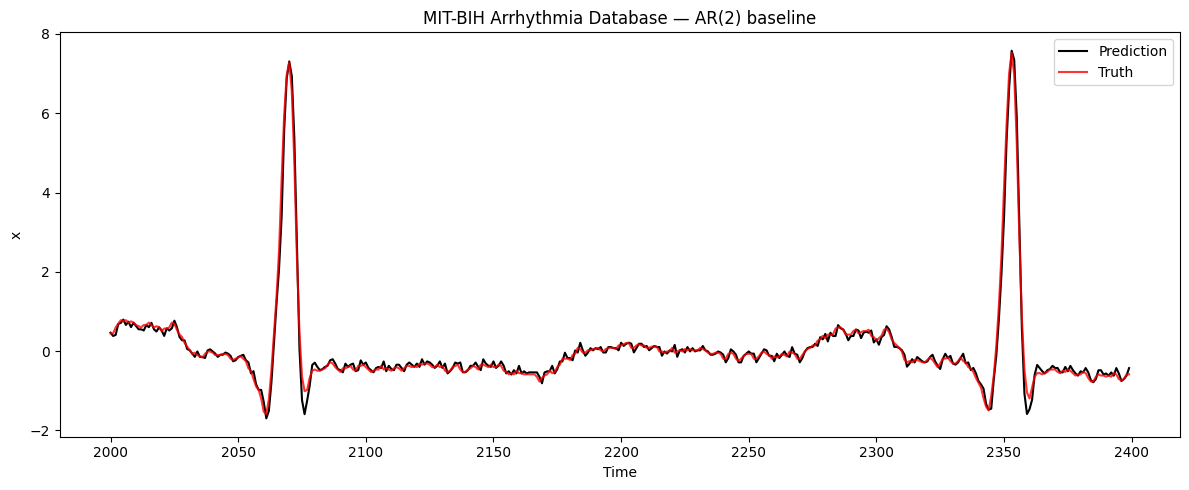

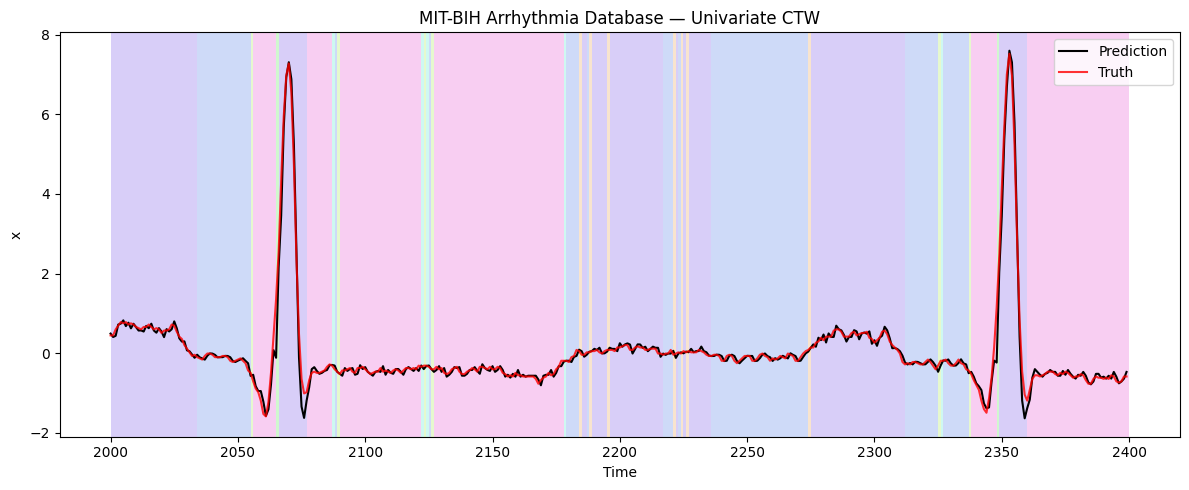

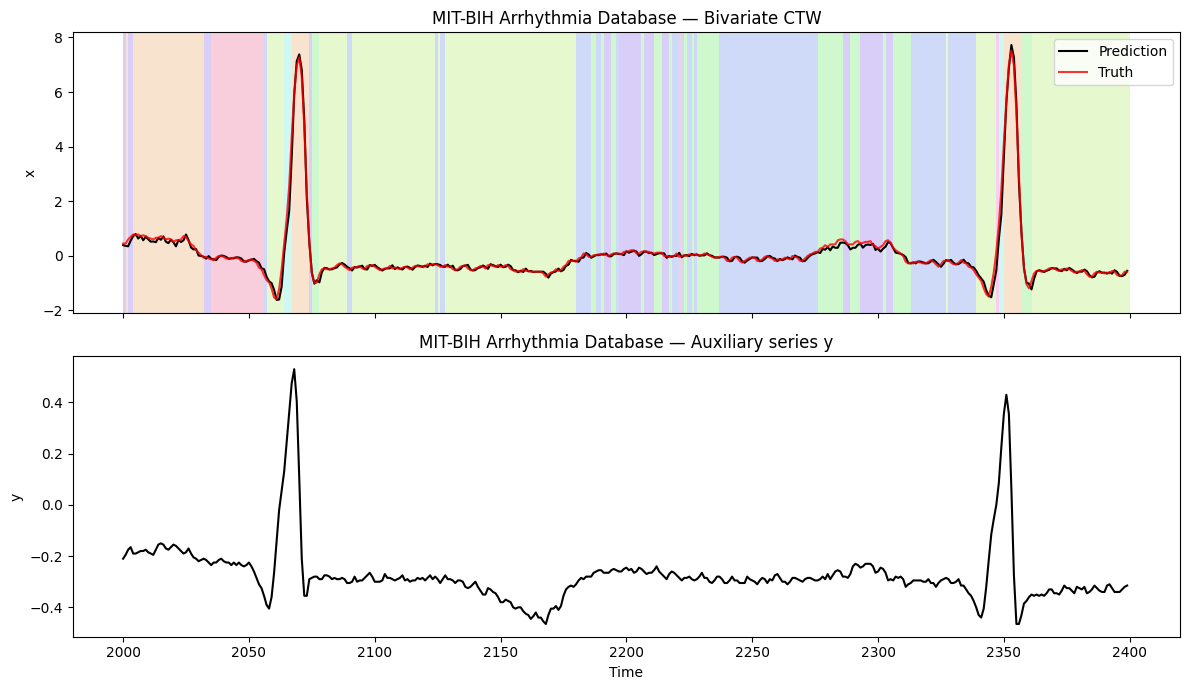

Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.100979,0.119317,0.377749,0.181093,0.856994,0.249120,2.550021,0.526466
ar,0.019845,0.091185,0.203529,0.212854,0.170700,0.255355,0.993591,0.496837
univariate,0.024020,0.086850,0.151069,0.176727,0.093656,0.167916,1.033967,0.373407
bivariate,0.030856,0.083602,0.111596,0.147579,0.109463,0.160434,0.749128,0.348333


In [79]:
ds = load_dataset("mitbih", n_samples=8000)

out = benchmark_methods(
    x=ds["x"],
    y=ds["y"],
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=50,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
    make_plots=True,
    n_samples_plot=400,
    plot_title_prefix=ds["name"],
)

pd.DataFrame(out["scores"]).T

[BIDMC-PPG] Chargement sujet 01…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.008626 | mae_1step=0.062197
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.96785455 -0.97952133]
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.96785455 -0.97952133]
[AR] mse_1step=0.000396 | mae_1step=0.015423
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train: 100%|██████████| 4/4 [00:02<00:00,  1.67it/s]


[Univariate CTW] Fit terminé.
[Univariate CTW] mse_1step=0.002757 | mae_1step=0.020688
[Bivariate CTW] Fit sur le train uniquement...
[Bivariate CTW] Initialisation du modèle (order=2, max_depth=3)


[Bivariate CTW] Observations train: 100%|██████████| 5600/5600 [00:00<00:00, 6066.16it/s]


[Bivariate CTW] Fit terminé.
[Bivariate CTW] mse_1step=0.000409 | mae_1step=0.015380
----------------------------------------------------------------------
[k-step] Évaluation horizon k=3


...

[lag1] k=3 | MSE=0.055095 | MAE=0.144255
[ar] k=3 | MSE=0.004617 | MAE=0.041857
[univariate] k=3 | MSE=0.029533 | MAE=0.065140
[bivariate] k=3 | MSE=0.004758 | MAE=0.042409
----------------------------------------------------------------------
[k-step] Évaluation horizon k=5


[Benchmark] Origines k=5: 100%|██████████| 50/50 [00:00<00:00, 1058.36it/s]


[lag1] k=5 | MSE=0.088087 | MAE=0.198508
[ar] k=5 | MSE=0.012666 | MAE=0.071024
[univariate] k=5 | MSE=0.083942 | MAE=0.124051
[bivariate] k=5 | MSE=0.010900 | MAE=0.071942
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10: 100%|██████████| 50/50 [00:00<00:00, 524.89it/s]


[lag1] k=10 | MSE=0.334491 | MAE=0.358292
[ar] k=10 | MSE=0.100049 | MAE=0.207556
[univariate] k=10 | MSE=0.276529 | MAE=0.290255
[bivariate] k=10 | MSE=0.092202 | MAE=0.190019


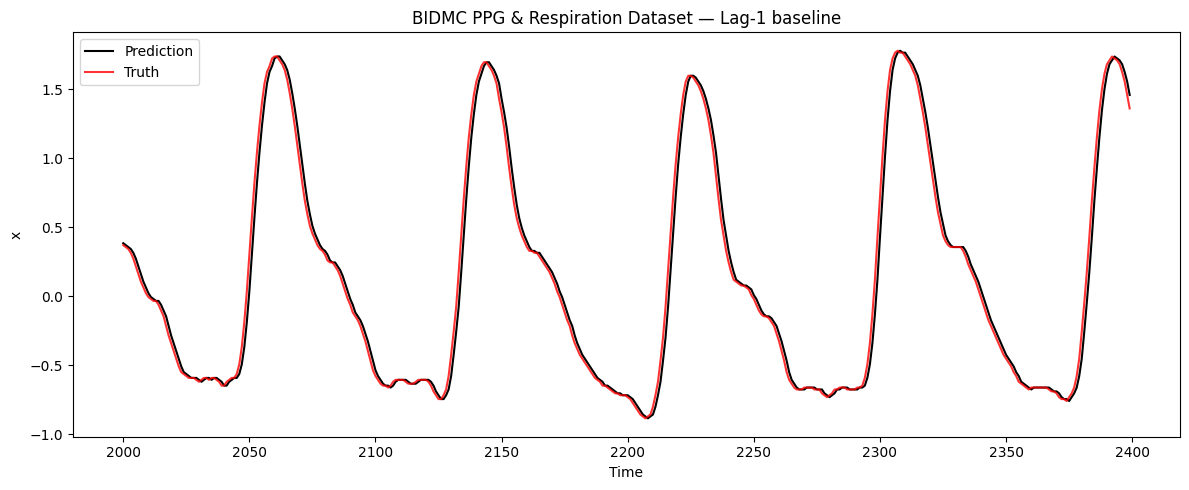

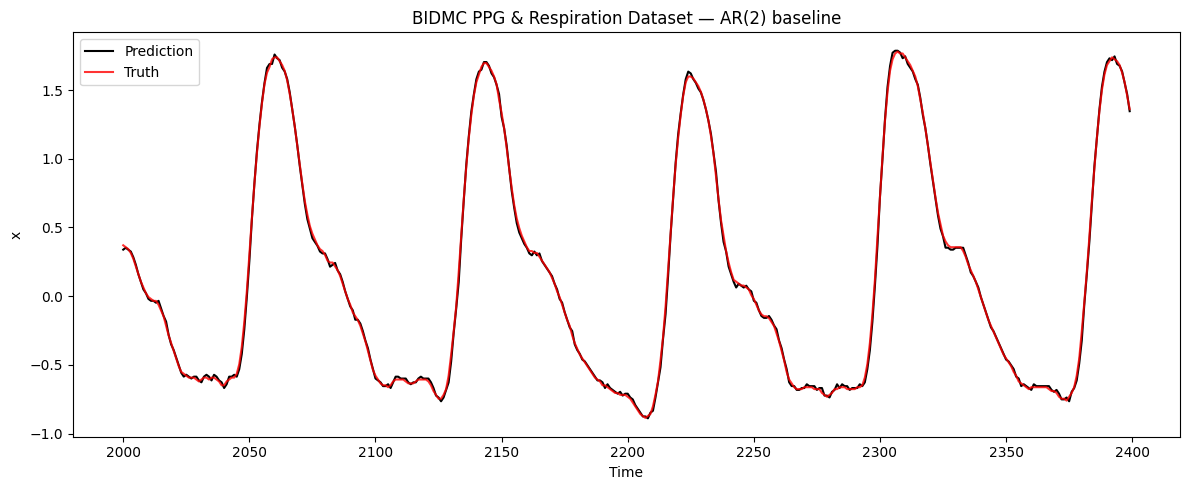

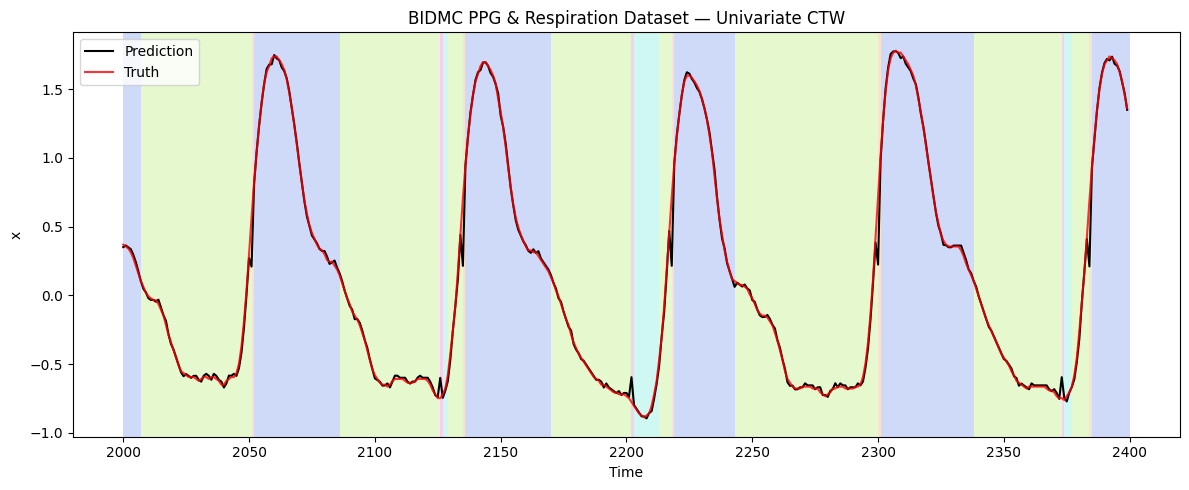

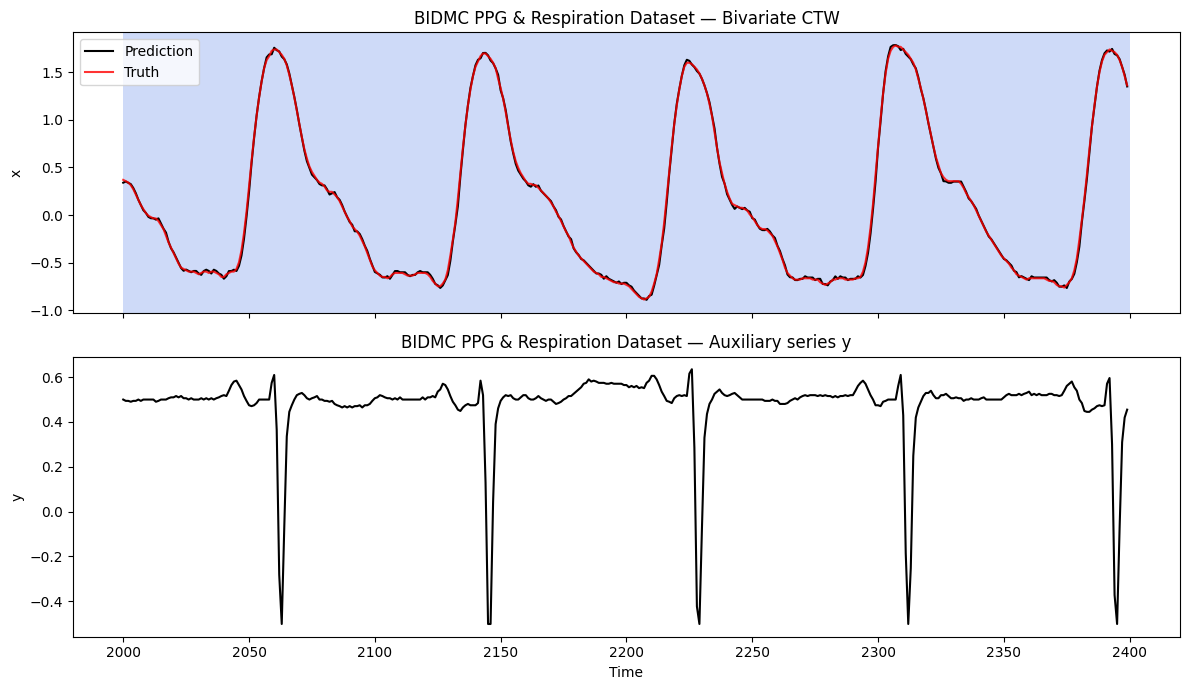

Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.100979,0.119317,0.377749,0.181093,0.856994,0.249120,2.550021,0.526466
ar,0.019845,0.091185,0.203529,0.212854,0.170700,0.255355,0.993591,0.496837
univariate,0.024020,0.086850,0.151069,0.176727,0.093656,0.167916,1.033967,0.373407
bivariate,0.030856,0.083602,0.111596,0.147579,0.109463,0.160434,0.749128,0.348333


In [80]:
ds = load_dataset("bidmc_ppg", n_samples=8000)

out = benchmark_methods(
    x=ds["x"],
    y=ds["y"],
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=50,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
    make_plots=True,
    n_samples_plot=400,
    plot_title_prefix=ds["name"],
)

pd.DataFrame(scores).T

In [46]:
ds = load_dataset("apnea_ecg", n_samples=8000)

scores = benchmark_methods(
    x=ds["x"],
    y=ds["y"],
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=50,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
)

pd.DataFrame(scores).T

[Apnea-ECG] Chargement enregistrement a01…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.719629 | mae_1step=0.304244
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=0.0001, coefs=[ 1.12025133 -0.64050844]
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=0.0001, coefs=[ 1.12025133 -0.64050844]
[AR] mse_1step=0.353665 | mae_1step=0.317708
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train: 100%|██████████| 4/4 [00:02<00:00,  1.71it/s]


[Univariate CTW] Fit terminé.
[Univariate CTW] mse_1step=0.547863 | mae_1step=0.306640
[Bivariate CTW] Fit sur le train uniquement...
[Bivariate CTW] Initialisation du modèle (order=2, max_depth=3)


[Bivariate CTW] Observations train: 100%|██████████| 5600/5600 [00:00<00:00, 6233.98it/s]


[Bivariate CTW] Fit terminé.
[Bivariate CTW] mse_1step=1.123756 | mae_1step=0.580862
----------------------------------------------------------------------
[k-step] Évaluation horizon k=3


...

[Benchmark] Origines k=5: 100%|██████████| 50/50 [00:00<00:00, 792.53it/s]


[lag1] k=5 | MSE=1.012152 | MAE=0.482995
[ar] k=5 | MSE=0.822931 | MAE=0.561423
[univariate] k=5 | MSE=1.125468 | MAE=0.501374
[bivariate] k=5 | MSE=0.934692 | MAE=0.555111
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10: 100%|██████████| 50/50 [00:00<00:00, 631.91it/s]


[lag1] k=10 | MSE=2.240880 | MAE=0.741829
[ar] k=10 | MSE=1.001582 | MAE=0.549057
[univariate] k=10 | MSE=1.082578 | MAE=0.550871
[bivariate] k=10 | MSE=1.178950 | MAE=0.564101
Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.719629,0.304244,1.054559,0.353834,1.012152,0.482995,2.240880,0.741829
ar,0.353665,0.317708,0.890030,0.500567,0.822931,0.561423,1.001582,0.549057
univariate,0.547863,0.306640,0.931859,0.383780,1.125468,0.501374,1.082578,0.550871
bivariate,1.123756,0.580862,0.917519,0.498154,0.934692,0.555111,1.178950,0.564101


In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests

CACHE_DIR = Path(os.environ.get("CTW_DATA_CACHE", "data/medical_cache"))
CACHE_DIR.mkdir(parents=True, exist_ok=True)

results = {}

def _download(url: str, dest: Path, chunk_size: int = 1 << 20):
    if dest.exists():
        print(f"Fichier déjà présent : {dest}")
        return
    print(f"Téléchargement : {url}")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    total = 0
    with open(dest, "wb") as f:
        for chunk in r.iter_content(chunk_size):
            if chunk:
                f.write(chunk)
                total += len(chunk)
    print(f"  -> {total / 1e6:.1f} MB écrits dans {dest}")

In [ ]:
import wfdb

record = "100"
n_samples = 10_000

print(f"[MIT-BIH] Chargement du record {record}")
sig, fields = wfdb.rdsamp(record, pn_dir="mitdb", sampto=n_samples)

x = sig[:, 0].astype(float)   # MLII
y = sig[:, 1].astype(float)   # V5

print("Shapes:", x.shape, y.shape)
print("Signal names:", fields["sig_name"])

res = predict_bivariate(x, y, online=False, plot_tree=False)
results["mitbih"] = {
    "dataset": "MIT-BIH Arrhythmia Database",
    "source": "https://physionet.org/content/mitdb/1.0.0/",
    "x_label": "ECG MLII",
    "y_label": "ECG V5",
    **res,
}
results["mitbih"]

TypeError: The parameter "keys" may be a column key, one-dimensional array, or a list containing only valid column keys and one-dimensional arrays.. Received column of type <class 'pandas.arrays.StringArray'>

# Analyse avec y, vibe-coded

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_bivariate_predictions(seq_x, seq_y, predictions, actuals, start_idx=0, window_plot=500):
    """
    seq_x, seq_y : séries complètes
    predictions, actuals : prédictions faites sur une sous-partie de la série
    start_idx : indice dans la série complète correspondant au début des prédictions
    """

    pred = np.asarray(predictions)
    act = np.asarray(actuals)

    # segment aligné de y correspondant aux prédictions
    y_seg = np.asarray(seq_y[start_idx:start_idx + len(pred)])
    x_seg = np.asarray(seq_x[start_idx:start_idx + len(pred)])

    # variations de y
    dy = np.diff(y_seg, prepend=y_seg[0])

    # seuil "forte variation" : 95e percentile des variations absolues
    shock_threshold = np.quantile(np.abs(dy), 0.95)
    shock_mask = np.abs(dy) >= shock_threshold
    shock_idx = np.where(shock_mask)[0]

    # erreurs
    errors = np.abs(pred - act)

    # fenêtre affichée
    n = len(pred)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 10))

    # 1) x réel vs prédit
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, act[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, pred[s:n], label="x prédit", alpha=0.8)
    for i in shock_idx:
        if s <= i < n:
            ax1.axvline(i, linestyle="--", alpha=0.2)
    ax1.legend()
    ax1.set_title("x vrai / x prédit + chocs de y")

    # 2) y et ses variations
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(idx, y_seg[s:n], label="y", alpha=0.8)
    shock_idx_window = [i for i in shock_idx if s <= i < n]
    ax2.scatter(shock_idx_window, y_seg[shock_idx_window], label="fortes variations de y", s=20)
    for i in shock_idx:
        if s <= i < n:
            ax2.axvline(i, linestyle="--", alpha=0.2)
    ax2.legend()
    ax2.set_title("Série y utilisée pour le contexte")

    # 3) erreur absolue
    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], label="|erreur|", alpha=0.8)
    for i in shock_idx:
        if s <= i < n:
            ax3.axvline(i, linestyle="--", alpha=0.2)
    ax3.legend()
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()

    return {
        "dy": dy,
        "shock_threshold": shock_threshold,
        "shock_idx": shock_idx,
        "errors":  errors ,
    }

def compare_errors_on_y_shocks(errors, dy, q=0.95):
    errors = np.asarray(errors)
    dy = np.asarray(dy)

    threshold = np.quantile(np.abs(dy), q)
    shock_mask = np.abs(dy) >= threshold
    normal_mask = ~shock_mask

    mean_error_shock = errors[shock_mask].mean() if shock_mask.any() else np.nan
    mean_error_normal = errors[normal_mask].mean() if normal_mask.any() else np.nan

    print(f"Seuil choc |Δy| (quantile {q:.2f}) : {threshold:.4f}")
    print(f"MAE pendant chocs de y        : {mean_error_shock:.4f}")
    print(f"MAE hors chocs de y           : {mean_error_normal:.4f}")
    print(f"Ratio choc / normal           : {mean_error_shock / mean_error_normal:.4f}")

    return {
        "threshold": threshold,
        "mean_error_shock": mean_error_shock,
        "mean_error_normal": mean_error_normal,
        "ratio": mean_error_shock / mean_error_normal,
    }

def y_bins_and_shocks(seq_y, quantizer):
    yq = np.array([quantizer.quantizers[1].quantize(v) for v in seq_y])
    dy = np.diff(seq_y, prepend=seq_y[0])
    y_bin_change = np.diff(yq, prepend=yq[0]) != 0
    return yq, dy, y_bin_change

def plot_y_bins(seq_y, quantizer, window_plot=500):
    yq, dy, y_bin_change = y_bins_and_shocks(seq_y, quantizer)

    n = len(seq_y)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, seq_y[s:n], label="y")
    changes = np.where(y_bin_change[s:n])[0] + s
    ax1.scatter(changes, np.array(seq_y)[changes], label="changement de bin y", s=20)
    ax1.legend()
    ax1.set_title("y et changements de quantification")

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, yq[s:n], where="post", label="bin(y)")
    ax2.legend()
    ax2.set_title("Quantification de y")

    plt.tight_layout()
    plt.show()

    

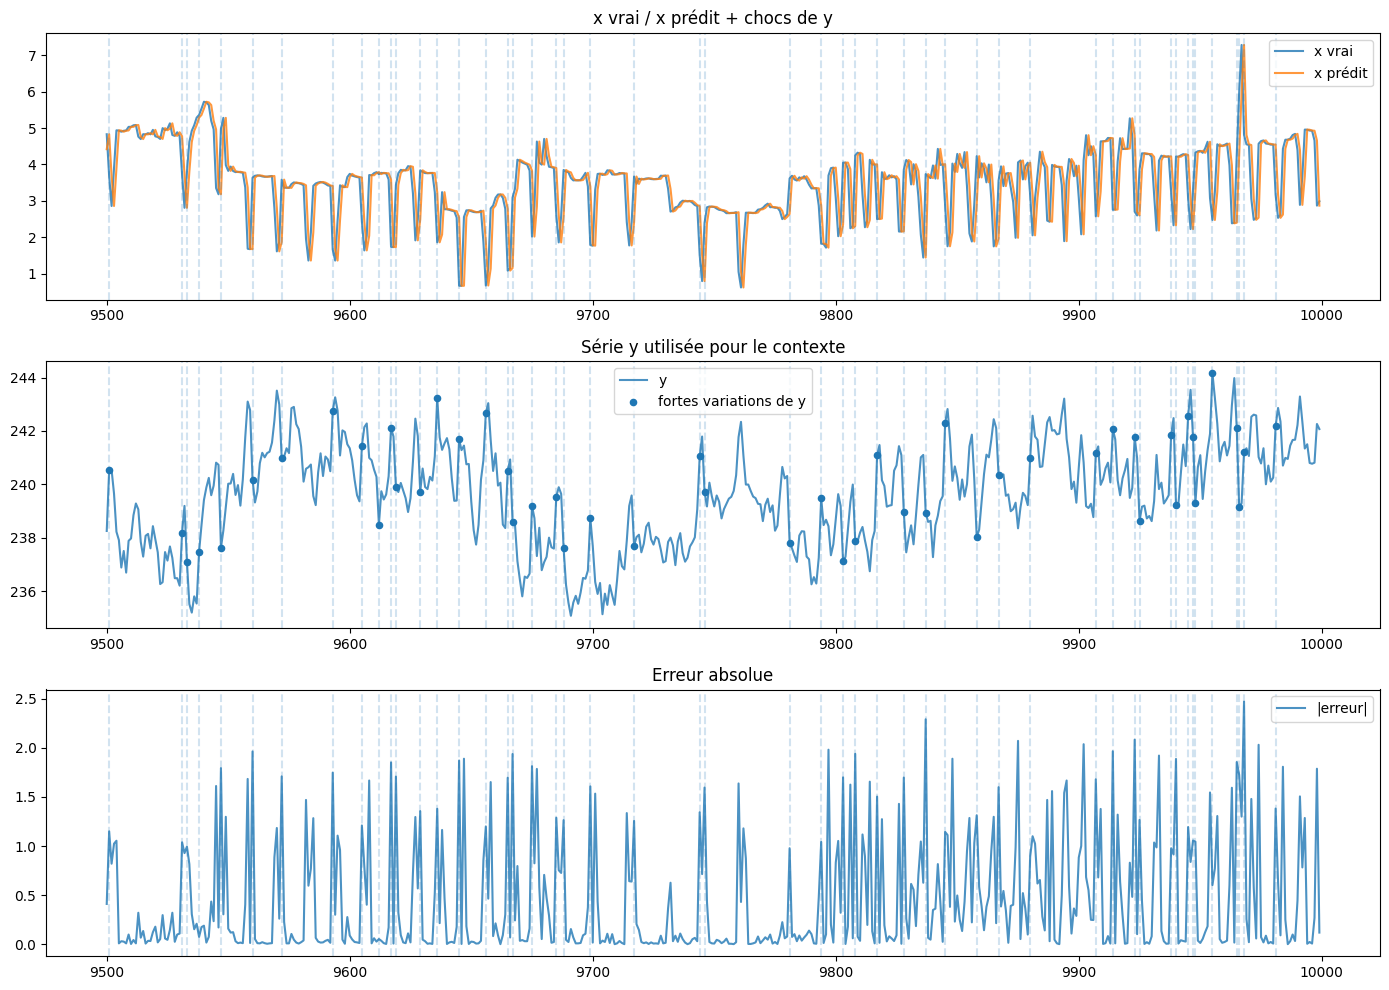

Seuil choc |Δy| (quantile 0.95) : 1.7400
MAE pendant chocs de y        : 1.3134
MAE hors chocs de y           : 0.1564
Ratio choc / normal           : 8.3983


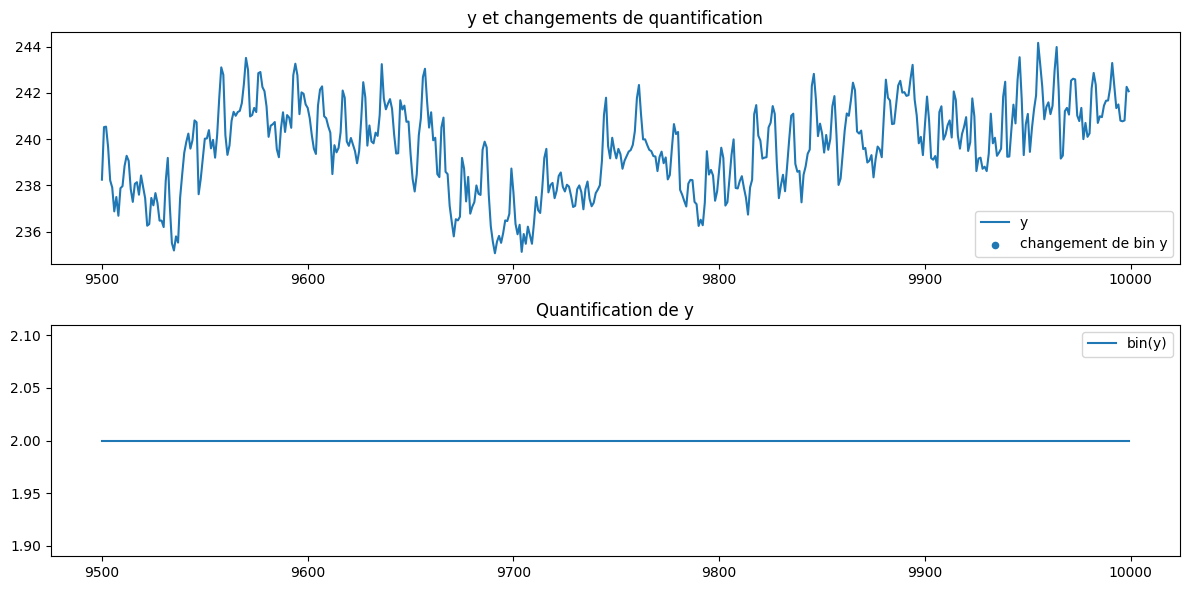

In [ ]:
results = analyze_bivariate_predictions(
    seq_x=seq_x,
    seq_y=seq_y,
    predictions=predictions,
    actuals=actuals,
    start_idx=0,
    window_plot=500
)

compare_errors_on_y_shocks(results["errors"], results["dy"], q=0.95)
plot_y_bins(seq_y, bq, window_plot=500)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree


def fit_predict_univariate_eval(
    seq_x,
    split=0.7,
    order=2,
    max_depth=2,
    beta=0.5,
    constant_term=True,
    n_passes_train=4,
    online=False,
):
    x = np.asarray(seq_x, dtype=float)
    n = len(x)
    split_idx = int(split * n)

    x_train_raw = x[:split_idx]
    x_test_raw = x[split_idx:]

    # standardisation sur train uniquement
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    x_scaled = (x - mu_x) / std_x
    x_train = x_scaled[:split_idx]
    x_test = x_scaled[split_idx:]

    quantizer = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    tree = LiveARTree(
        max_depth=max_depth,
        order=order,
        constant_term=constant_term,
        quantizer=quantizer,
        beta=beta,
    )

    # fit train
    for _ in range(n_passes_train):
        for x_i in x_train:
            tree.observe(float(x_i))

    predictions_scaled = []
    actuals_scaled = []

    # historique glissant, même en offline
    x_seen = list(x_train)

    for x_i in x_test:
        history = np.array(x_seen[-order:], dtype=float)
        pred = tree.predict(history)
        predictions_scaled.append(float(pred))
        actuals_scaled.append(float(x_i))

        x_seen.append(float(x_i))
        if online:
            tree.observe(float(x_i))

    predictions_scaled = np.asarray(predictions_scaled)
    actuals_scaled = np.asarray(actuals_scaled)

    # retour en unités originales de x pour interpréter la MAE
    predictions = predictions_scaled * std_x + mu_x
    actuals = actuals_scaled * std_x + mu_x
    errors = np.abs(predictions - actuals)

    return {
        "model": "univariate",
        "split_idx": split_idx,
        "predictions": predictions,
        "actuals": actuals,
        "errors": errors,
        "x_test_raw": x_test_raw,
        "x_train_raw": x_train_raw,
        "quantizer": quantizer,
        "tree": tree,
    }


def fit_predict_bivariate_eval(
    seq_x,
    seq_y,
    split=0.7,
    order=2,
    max_depth=3,
    beta=0.5,
    constant_term=False,
    online=False,
):
    x = np.asarray(seq_x, dtype=float)
    y = np.asarray(seq_y, dtype=float)
    n = len(x)
    split_idx = int(split * n)

    x_train_raw = x[:split_idx]
    x_test_raw = x[split_idx:]
    y_train_raw = y[:split_idx]
    y_test_raw = y[split_idx:]

    # standardisation sur train uniquement
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    mu_y = y_train_raw.mean()
    std_y = y_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    y_scaled = (y - mu_y) / std_y

    x_train = x_scaled[:split_idx]
    x_test = x_scaled[split_idx:]
    y_train = y_scaled[:split_idx]
    y_test = y_scaled[split_idx:]

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    thresholds = np.array([qx, qy], dtype=float)

    bq = BivariateQuantizer(thresholds=thresholds)
    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        constant_term=constant_term,
        quantizer=bq,
        beta=beta,
    )

    # fit train
    for x_i, y_i in zip(x_train, y_train):
        tree.observe(float(x_i), float(y_i))

    predictions_scaled = []
    actuals_scaled = []

    # historique glissant, même en offline
    x_seen = list(x_train)
    y_seen = list(y_train)

    hist_len = max(max_depth, order)

    for x_i, y_i in zip(x_test, y_test):
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        pred = tree.predict(history)
        predictions_scaled.append(float(pred))
        actuals_scaled.append(float(x_i))

        x_seen.append(float(x_i))
        y_seen.append(float(y_i))
        if online:
            tree.observe(float(x_i), float(y_i))

    predictions_scaled = np.asarray(predictions_scaled)
    actuals_scaled = np.asarray(actuals_scaled)

    predictions = predictions_scaled * std_x + mu_x
    actuals = actuals_scaled * std_x + mu_x
    errors = np.abs(predictions - actuals)

    return {
        "model": "bivariate",
        "split_idx": split_idx,
        "predictions": predictions,
        "actuals": actuals,
        "errors": errors,
        "x_test_raw": x_test_raw,
        "y_test_raw": y_test_raw,
        "x_train_raw": x_train_raw,
        "y_train_raw": y_train_raw,
        "quantizer": bq,
        "tree": tree,
    }


def compute_lagged_y_shocks(seq_y, split_idx, q=0.95):
    """
    Choc de y aligné avec la prédiction de x_t :
    on utilise ici le dernier choc observable avant de prédire x_t,
    donc |y_{t-1} - y_{t-2}|.
    """
    y = np.asarray(seq_y, dtype=float)
    n_test = len(y) - split_idx

    shock_values = []
    for t in range(split_idx, len(y)):
        if t >= 2:
            shock_values.append(abs(y[t - 1] - y[t - 2]))
        elif t >= 1:
            shock_values.append(abs(y[t - 1] - y[t - 1]))
        else:
            shock_values.append(0.0)

    shock_values = np.asarray(shock_values)
    threshold = np.quantile(shock_values, q)
    shock_mask = shock_values >= threshold
    return shock_values, threshold, shock_mask


def summarize_error_by_mask(errors, mask, label):
    errors = np.asarray(errors)
    mask = np.asarray(mask, dtype=bool)

    mae_sel = errors[mask].mean() if mask.any() else np.nan
    mae_other = errors[~mask].mean() if (~mask).any() else np.nan

    print(f"{label}")
    print(f"  n zone          : {mask.sum()}")
    print(f"  MAE zone        : {mae_sel:.6f}")
    print(f"  MAE hors zone   : {mae_other:.6f}")
    print(f"  ratio zone/hors : {mae_sel / mae_other:.6f}" if np.isfinite(mae_sel) and np.isfinite(mae_other) and mae_other != 0 else "  ratio zone/hors : nan")

    return {
        "n": int(mask.sum()),
        "mae_zone": mae_sel,
        "mae_other": mae_other,
        "ratio": mae_sel / mae_other if np.isfinite(mae_sel) and np.isfinite(mae_other) and mae_other != 0 else np.nan,
    }


def compare_univariate_bivariate_on_y(
    seq_x,
    seq_y,
    split=0.7,
    q_shock=0.95,
    top_k=20,
    online=False,
    plot_window=300,
):
    uni = fit_predict_univariate_eval(seq_x, split=split, online=online)
    bi = fit_predict_bivariate_eval(seq_x, seq_y, split=split, online=online)

    # alignement
    pred_u = uni["predictions"]
    pred_b = bi["predictions"]
    act = bi["actuals"]

    err_u = np.abs(pred_u - act)
    err_b = np.abs(pred_b - act)
    gain = err_u - err_b

    mae_u = err_u.mean()
    mae_b = err_b.mean()

    print("MAE globale")
    print(f"  univarié : {mae_u:.6f}")
    print(f"  bivarié  : {mae_b:.6f}")
    print(f"  gain abs : {mae_u - mae_b:.6f}")
    print(f"  gain rel : {(mae_u - mae_b) / mae_u * 100:.2f} %")

    # chocs de y observables avant la prédiction
    shock_values, shock_threshold, shock_mask = compute_lagged_y_shocks(seq_y, bi["split_idx"], q=q_shock)

    print("")
    print(f"Chocs de y")
    print(f"  seuil |Δy_lag| q={q_shock:.2f} : {shock_threshold:.6f}")

    stats_uni_shock = summarize_error_by_mask(err_u, shock_mask, "Univarié sur chocs de y")
    stats_bi_shock = summarize_error_by_mask(err_b, shock_mask, "Bivarié sur chocs de y")

    print("")
    print("Comparaison directe sur chocs de y")
    print(f"  MAE uni choc : {err_u[shock_mask].mean():.6f}" if shock_mask.any() else "  MAE uni choc : nan")
    print(f"  MAE bi choc  : {err_b[shock_mask].mean():.6f}" if shock_mask.any() else "  MAE bi choc  : nan")
    if shock_mask.any():
        print(f"  gain choc    : {(err_u[shock_mask].mean() - err_b[shock_mask].mean()):.6f}")

    # top erreurs univariées
    top_k = min(top_k, len(err_u))
    top_idx = np.argsort(err_u)[-top_k:]
    top_mask = np.zeros_like(err_u, dtype=bool)
    top_mask[top_idx] = True

    print("")
    print(f"Top {top_k} plus grosses erreurs du modèle univarié")
    print(f"  MAE uni topK : {err_u[top_mask].mean():.6f}")
    print(f"  MAE bi topK  : {err_b[top_mask].mean():.6f}")
    print(f"  gain topK    : {(err_u[top_mask].mean() - err_b[top_mask].mean()):.6f}")
    print(f"  points où bi fait mieux sur topK : {(gain[top_mask] > 0).mean() * 100:.1f} %")

    # visualisation
    n = len(act)
    s = max(0, n - plot_window)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(4, 1, 1)
    ax1.plot(idx, act[s:], label="x vrai", alpha=0.8)
    ax1.plot(idx, pred_u[s:], label="pred uni", alpha=0.8)
    ax1.plot(idx, pred_b[s:], label="pred bi", alpha=0.8)
    ax1.legend()
    ax1.set_title("Comparaison prédictions")

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    y_test = np.asarray(seq_y[bi["split_idx"]:])
    ax2.plot(idx, y_test[s:], label="y test", alpha=0.8)
    shock_idx = np.where(shock_mask)[0]
    shock_idx = shock_idx[(shock_idx >= s) & (shock_idx < n)]
    if len(shock_idx) > 0:
        ax2.scatter(shock_idx, y_test[shock_idx], s=20, label="chocs de y")
    ax2.legend()
    ax2.set_title("Signal y et chocs")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(idx, err_u[s:], label="|err| uni", alpha=0.8)
    ax3.plot(idx, err_b[s:], label="|err| bi", alpha=0.8)
    ax3.legend()
    ax3.set_title("Erreurs absolues")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.plot(idx, gain[s:], label="gain = err_uni - err_bi", alpha=0.8)
    ax4.axhline(0.0, color="black", linestyle="--", alpha=0.5)
    ax4.legend()
    ax4.set_title("Gain du bivarié")
    plt.tight_layout()
    plt.show()

    return {
        "uni": uni,
        "bi": bi,
        "actuals": act,
        "pred_uni": pred_u,
        "pred_bi": pred_b,
        "err_uni": err_u,
        "err_bi": err_b,
        "gain": gain,
        "shock_values": shock_values,
        "shock_threshold": shock_threshold,
        "shock_mask": shock_mask,
        "stats_uni_shock": stats_uni_shock,
        "stats_bi_shock": stats_bi_shock,
        "top_idx_uni": top_idx,
    }


MAE globale
  univarié : 0.358779
  bivarié  : 0.352052
  gain abs : 0.006727
  gain rel : 1.88 %

Chocs de y
  seuil |Δy_lag| q=0.95 : 1.940500
Univarié sur chocs de y
  n zone          : 150
  MAE zone        : 0.814615
  MAE hors zone   : 0.334788
  ratio zone/hors : 2.433230
Bivarié sur chocs de y
  n zone          : 150
  MAE zone        : 0.699922
  MAE hors zone   : 0.333743
  ratio zone/hors : 2.097190

Comparaison directe sur chocs de y
  MAE uni choc : 0.814615
  MAE bi choc  : 0.699922
  gain choc    : 0.114694

Top 30 plus grosses erreurs du modèle univarié
  MAE uni topK : 2.422406
  MAE bi topK  : 1.559571
  gain topK    : 0.862835
  points où bi fait mieux sur topK : 86.7 %


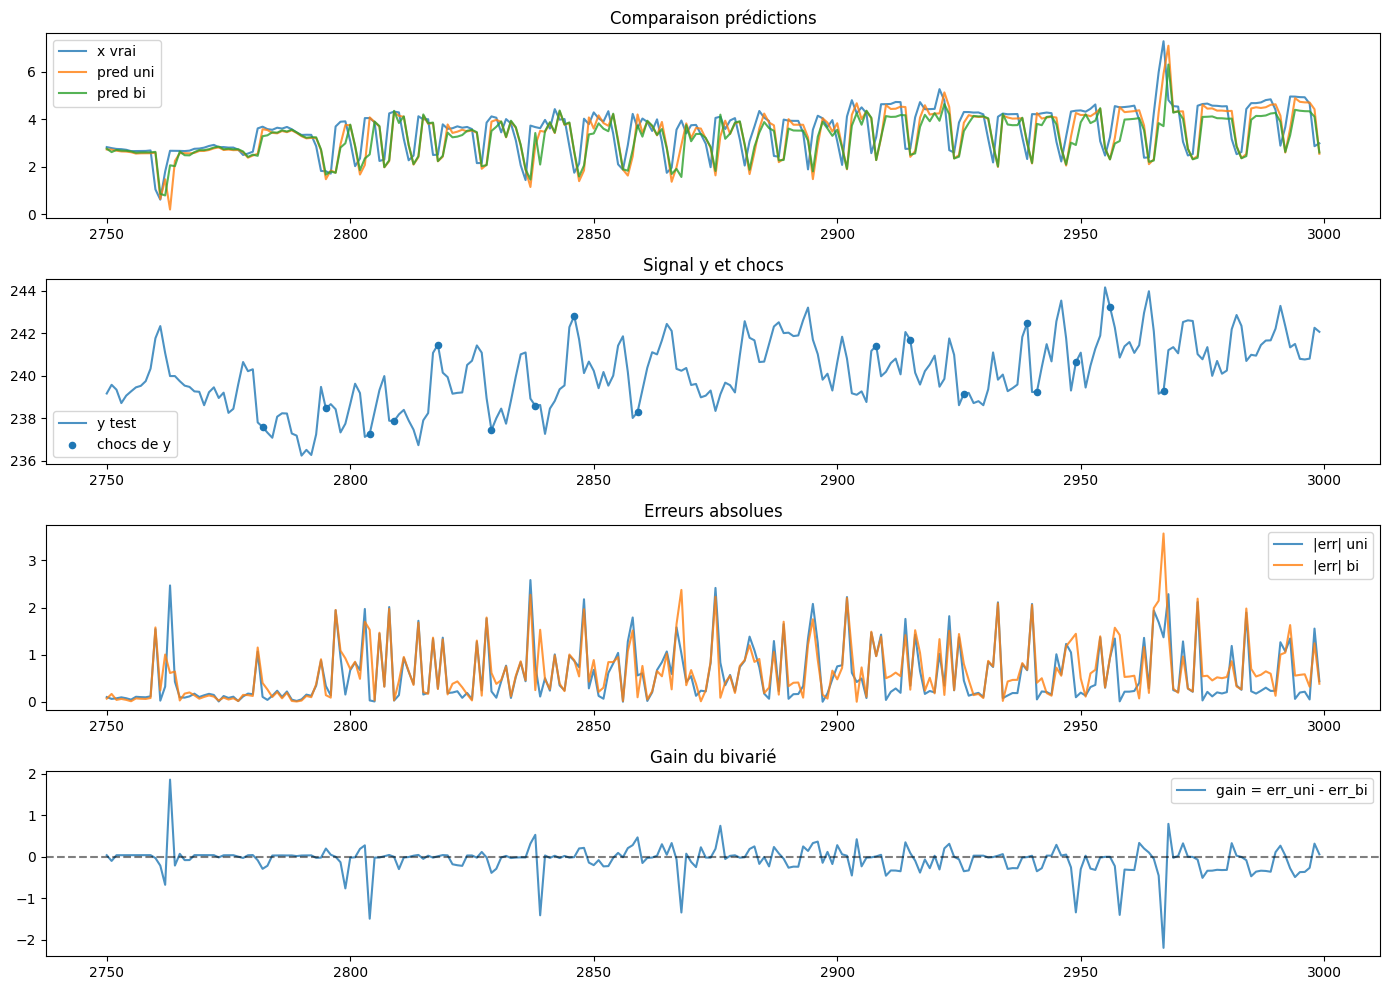

In [ ]:
res = compare_univariate_bivariate_on_y(
    seq_x,
    seq_y,
    split=0.7,
    q_shock=0.95,
    top_k=30,
    online=False,
    plot_window=250,
)


In [62]:
import numpy as np
import matplotlib.pyplot as plt

from ctw.models import Quantizer, LiveARTree, BivariateQuantizer, BivariateARTree


def fit_univariate_for_trace(seq_x, split=0.7, order=2, max_depth=2, beta=0.5, constant_term=True, n_passes_train=4):
    x = np.asarray(seq_x, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    x_train = x_scaled[:split_idx]

    q = Quantizer(thresholds=np.quantile(x_train, [0.33, 0.66]))
    tree = LiveARTree(max_depth=max_depth, order=order, constant_term=constant_term, quantizer=q, beta=beta)

    for _ in range(n_passes_train):
        for x_i in x_train:
            tree.observe(float(x_i))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": q,
    }


def fit_bivariate_for_trace(seq_x, seq_y, split=0.7, order=2, max_depth=3, beta=0.5, constant_term=False):
    x = np.asarray(seq_x, dtype=float)
    y = np.asarray(seq_y, dtype=float)
    split_idx = int(split * len(x))

    x_train_raw = x[:split_idx]
    y_train_raw = y[:split_idx]

    mu_x = x_train_raw.mean()
    std_x = x_train_raw.std()
    mu_y = y_train_raw.mean()
    std_y = y_train_raw.std()

    x_scaled = (x - mu_x) / std_x
    y_scaled = (y - mu_y) / std_y

    x_train = x_scaled[:split_idx]
    y_train = y_scaled[:split_idx]

    qx = np.quantile(x_train, [0.33, 0.66])
    qy = np.quantile(y_train, [0.33, 0.66])
    bq = BivariateQuantizer(thresholds=np.array([qx, qy], dtype=float))

    tree = BivariateARTree(
        order=order,
        max_depth=max_depth,
        constant_term=constant_term,
        quantizer=bq,
        beta=beta,
    )

    for x_i, y_i in zip(x_train, y_train):
        tree.observe(float(x_i), float(y_i))

    return {
        "tree": tree,
        "x_scaled": x_scaled,
        "y_scaled": y_scaled,
        "split_idx": split_idx,
        "mu_x": mu_x,
        "std_x": std_x,
        "mu_y": mu_y,
        "std_y": std_y,
        "order": order,
        "max_depth": max_depth,
        "constant_term": constant_term,
        "quantizer": bq,
    }


def _select_node_univariate(tree, history):
    history = np.asarray(history, dtype=float)[::-1]
    context_to_navigate = [tree.quantizer.quantize(v) for v in history[:tree.max_depth]][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node


def _select_node_bivariate(tree, history):
    history = np.asarray(history, dtype=float)[:, ::-1]
    bi_context = [history[:tree.max_depth, k] for k in range(history.shape[1])]
    context_to_navigate = [tree.quantizer.quantize(v) for v in bi_context][::-1]

    node = tree.tree.root
    depth = 0
    while not node.data["leaf_cbct"] and depth < tree.max_depth:
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1
    return node


def trace_univariate_regimes(seq_x, split=0.7, online=False):
    fit = fit_univariate_for_trace(seq_x, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    split_idx = fit["split_idx"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []

    x_seen = list(x_scaled[:split_idx])

    for t in range(split_idx, len(x_scaled)):
        history = np.array(x_seen[-order:], dtype=float)
        node = _select_node_univariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        x_seen.append(float(x_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]))

    preds = np.asarray(preds, dtype=float) 
    actuals = np.asarray(actuals, dtype=float) 

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "split_idx": split_idx,
    }


def trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False):
    fit = fit_bivariate_for_trace(seq_x, seq_y, split=split)
    tree = fit["tree"]
    x_scaled = fit["x_scaled"]
    y_scaled = fit["y_scaled"]
    split_idx = fit["split_idx"]
    max_depth = fit["max_depth"]
    order = fit["order"]

    preds = []
    actuals = []
    contexts = []
    depths = []
    coeffs = []
    vars_ = []
    y_bin_lag = []

    x_seen = list(x_scaled[:split_idx])
    y_seen = list(y_scaled[:split_idx])

    hist_len = max(max_depth, order)

    for t in range(split_idx, len(x_scaled)):
        history = np.array([
            x_seen[-hist_len:],
            y_seen[-hist_len:],
        ], dtype=float)

        node = _select_node_bivariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_scaled[t])
        contexts.append(tuple(node.context))
        depths.append(len(node.context))
        coeffs.append(np.array(node.data["ms"]).reshape(-1).copy())
        vars_.append(float(np.asarray(node.data["var"]).squeeze()))

        y_last = y_seen[-1]
        y_bin_lag.append(tree.quantizer.quantizers[1].quantize(y_last))

        x_seen.append(float(x_scaled[t]))
        y_seen.append(float(y_scaled[t]))
        if online:
            tree.observe(float(x_scaled[t]), float(y_scaled[t]))

    preds = np.asarray(preds) * fit["std_x"] + fit["mu_x"]
    actuals = np.asarray(actuals) * fit["std_x"] + fit["mu_x"]

    return {
        "predictions": preds,
        "actuals": actuals,
        "errors": np.abs(preds - actuals),
        "contexts": contexts,
        "depths": np.asarray(depths),
        "coeffs": coeffs,
        "vars": np.asarray(vars_),
        "y_bin_lag": np.asarray(y_bin_lag),
        "split_idx": split_idx,
    }


def context_to_regime_ids(contexts):
    mapping = {}
    ids = []
    next_id = 0
    for ctx in contexts:
        if ctx not in mapping:
            mapping[ctx] = next_id
            next_id += 1
        ids.append(mapping[ctx])
    return np.asarray(ids), mapping


def regime_switch_mask(regime_ids):
    regime_ids = np.asarray(regime_ids)
    if len(regime_ids) == 0:
        return np.array([], dtype=bool)
    out = np.zeros(len(regime_ids), dtype=bool)
    out[1:] = regime_ids[1:] != regime_ids[:-1]
    return out


def plot_regime_timeline(actuals, predictions, regime_ids, title="AR regimes over time", window_plot=300):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    regime_ids = np.asarray(regime_ids)

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(14, 7))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, actuals[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, predictions[s:n], label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, regime_ids[s:n], where="post", label="regime id")
    switches = np.where(regime_switch_mask(regime_ids))[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax2.scatter(switches, regime_ids[switches], s=20, label="switch")
    ax2.legend()
    ax2.set_title("Régime AR sélectionné")

    plt.tight_layout()
    plt.show()


def plot_regime_zones(actuals, predictions, regime_ids, errors=None, window_plot=300, title="Zones de régimes AR"):
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    regime_ids = np.asarray(regime_ids)
    errors = np.abs(predictions - actuals) if errors is None else np.asarray(errors)

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    unique_regimes = np.unique(regime_ids)
    cmap = plt.cm.get_cmap("tab20", max(20, len(unique_regimes)))
    color_map = {r: cmap(i % cmap.N) for i, r in enumerate(unique_regimes)}

    plt.figure(figsize=(14, 9))

    ax1 = plt.subplot(3, 1, 1)
    start = s
    current = regime_ids[s]
    for t in range(s + 1, n + 1):
        if t == n or regime_ids[t] != current:
            ax1.axvspan(start, t - 1, color=color_map[current], alpha=0.18)
            if t < n:
                start = t
                current = regime_ids[t]
    ax1.plot(idx, actuals[s:n], color="black", label="x vrai", linewidth=1.5)
    ax1.plot(idx, predictions[s:n], color="tab:red", label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, regime_ids[s:n], where="post", color="tab:blue")
    ax2.set_title("Identifiant du régime")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], color="tab:orange")
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()


def compare_regime_interpretation(seq_x, seq_y, split=0.7, online=False, window_plot=300):
    uni = trace_univariate_regimes(seq_x, split=split, online=online)
    bi = trace_bivariate_regimes(seq_x, seq_y, split=split, online=online)

    reg_u, map_u = context_to_regime_ids(uni["contexts"])
    reg_b, map_b = context_to_regime_ids(bi["contexts"])

    sw_u = regime_switch_mask(reg_u)
    sw_b = regime_switch_mask(reg_b)

    err_u = uni["errors"]
    err_b = bi["errors"]
    gain = err_u - err_b

    y_test = np.asarray(seq_y[bi["split_idx"]:])
    y_bin = bi["y_bin_lag"]
    y_bin_switch = regime_switch_mask(y_bin)

    print("MAE globale")
    print(f"  univarié : {err_u.mean():.6f}")
    print(f"  bivarié  : {err_b.mean():.6f}")
    print(f"  gain     : {(err_u.mean() - err_b.mean()):.6f}")

    print("")
    print("Switch de régime")
    print(f"  nb switch uni : {sw_u.sum()}")
    print(f"  nb switch bi  : {sw_b.sum()}")

    only_bi_switch = sw_b & (~sw_u)
    if only_bi_switch.any():
        print("")
        print("Quand le bivarié change de régime et pas l'univarié")
        print(f"  MAE uni : {err_u[only_bi_switch].mean():.6f}")
        print(f"  MAE bi  : {err_b[only_bi_switch].mean():.6f}")
        print(f"  gain    : {(err_u[only_bi_switch].mean() - err_b[only_bi_switch].mean()):.6f}")
        print(f"  part des points où bi aide : {(gain[only_bi_switch] > 0).mean() * 100:.1f} %")

    if y_bin_switch.any():
        print("")
        print("Lien avec les changements de bin de y")
        print(f"  P(switch bi | switch bin(y)) = {(sw_b[y_bin_switch]).mean():.3f}")
        print(f"  P(switch uni | switch bin(y)) = {(sw_u[y_bin_switch]).mean():.3f}")
        print(f"  gain moyen bi sur switch bin(y) = {gain[y_bin_switch].mean():.6f}")

    plot_regime_timeline(
        uni["actuals"],
        uni["predictions"],
        reg_u,
        title="Régimes AR univariés",
        window_plot=window_plot,
    )

    plot_regime_timeline(
        bi["actuals"],
        bi["predictions"],
        reg_b,
        title="Régimes AR bivariés",
        window_plot=window_plot,
    )

    plot_regime_zones(
        bi["actuals"],
        bi["predictions"],
        reg_b,
        errors=bi["errors"],
        window_plot=window_plot,
        title="Zones de régimes AR du modèle bivarié",
    )

    plt.figure(figsize=(14, 8))

    n = len(y_test)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, y_test[s:n], label="y", alpha=0.8)
    sw_idx = np.where(sw_b)[0]
    sw_idx = sw_idx[(sw_idx >= s) & (sw_idx < n)]
    if len(sw_idx) > 0:
        ax1.scatter(sw_idx, y_test[sw_idx], s=20, label="switch régime bi")
    ax1.legend()
    ax1.set_title("y et changements de régime bivarié")

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, y_bin[s:n], where="post", label="bin(y_{t-1})")
    y_sw_idx = np.where(y_bin_switch)[0]
    y_sw_idx = y_sw_idx[(y_sw_idx >= s) & (y_sw_idx < n)]
    if len(y_sw_idx) > 0:
        ax2.scatter(y_sw_idx, y_bin[y_sw_idx], s=20, label="switch bin(y)")
    ax2.legend()
    ax2.set_title("Quantification de y")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, gain[s:n], label="gain = err_uni - err_bi", alpha=0.8)
    ax3.axhline(0.0, color="black", linestyle="--", alpha=0.5)
    ax3.legend()
    ax3.set_title("Gain du bivarié")

    plt.tight_layout()
    plt.show()

    return {
        "uni": uni,
        "bi": bi,
        "regime_ids_uni": reg_u,
        "regime_ids_bi": reg_b,
        "switch_uni": sw_u,
        "switch_bi": sw_b,
        "y_bin": y_bin,
        "y_bin_switch": y_bin_switch,
        "gain": gain,
        "contexts_uni_map": map_u,
        "contexts_bi_map": map_b,
    }


MAE globale
  univarié : 0.358779
  bivarié  : 0.352052
  gain     : 0.006727

Switch de régime
  nb switch uni : 672
  nb switch bi  : 913

Quand le bivarié change de régime et pas l'univarié
  MAE uni : 0.310950
  MAE bi  : 0.331466
  gain    : -0.020517
  part des points où bi aide : 48.5 %

Lien avec les changements de bin de y
  P(switch bi | switch bin(y)) = 0.653
  P(switch uni | switch bin(y)) = 0.456
  gain moyen bi sur switch bin(y) = 0.045313


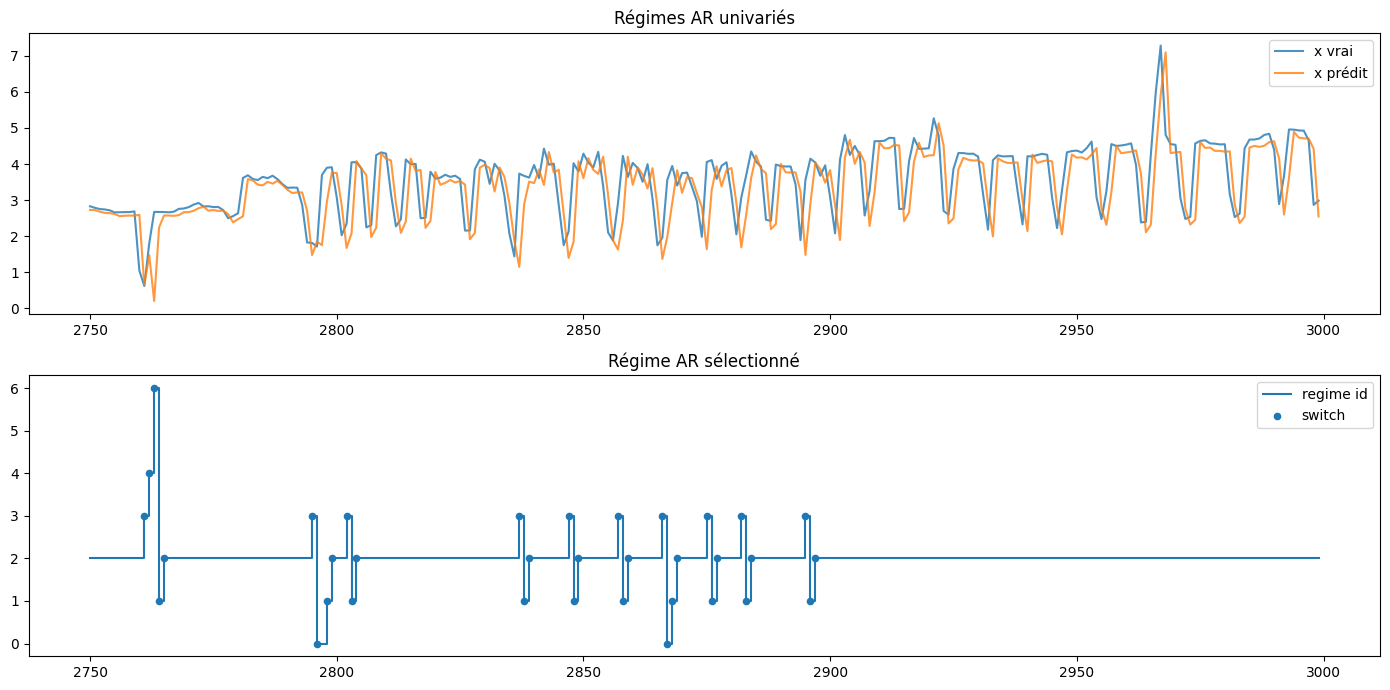

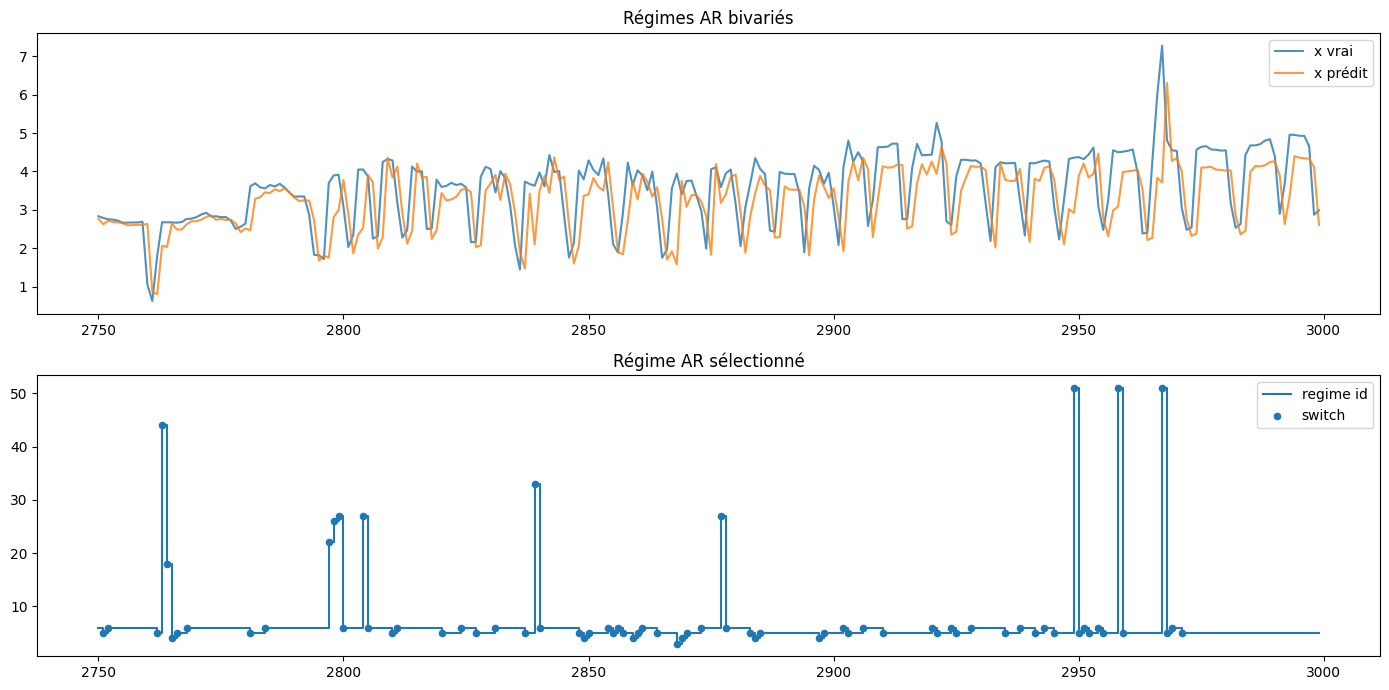

/var/folders/dr/v65kt4vd74b0bqgk5_sy5npr0000gn/T/ipykernel_308/1014631714.py:300: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(20, len(unique_regimes)))


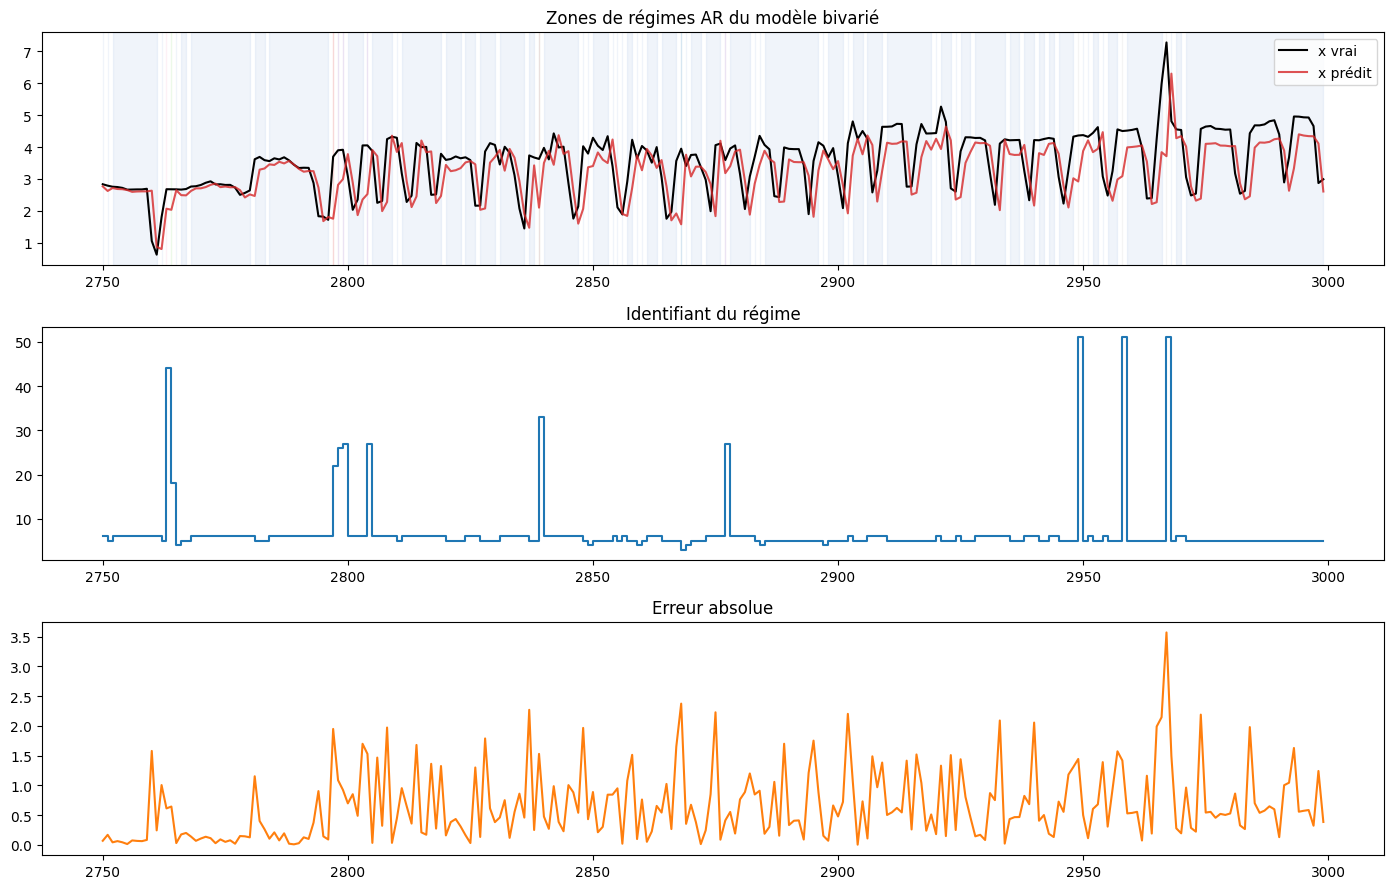

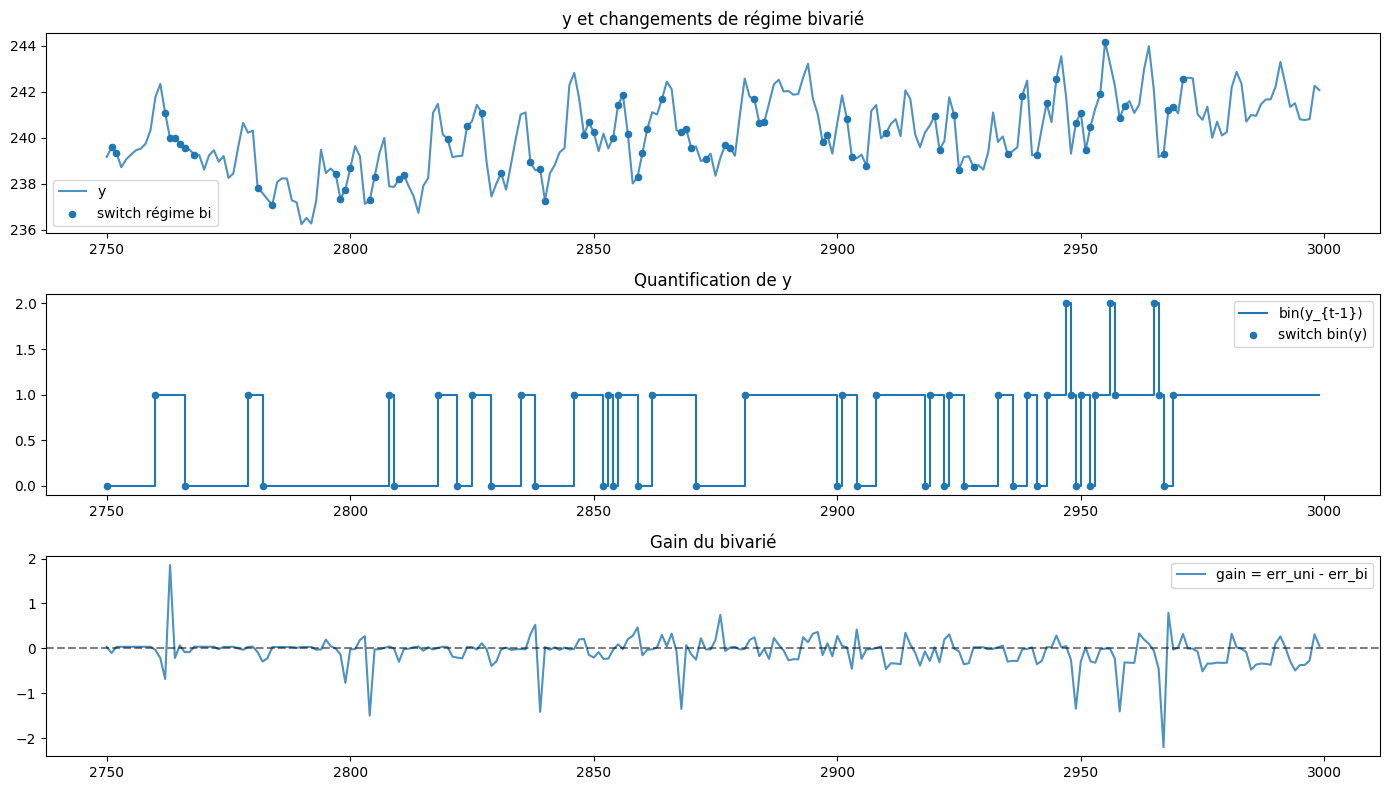

In [ ]:
res_reg = compare_regime_interpretation(
    seq_x,
    seq_y,
    split=0.7,
    online=False,
    window_plot=250,
)


In [63]:
import numpy as np
import matplotlib.pyplot as plt


def format_univariate_context(context):
    """
    context: tuple/list d'indices de bins de x
    Ex: (2, 0) -> "[x2 | x0]"
    """
    if context is None or len(context) == 0:
        return "root"
    return "[" + " | ".join(f"x{int(c)}" for c in context) + "]"


def format_bivariate_context(context, quantizer, compact=True):
    """
    context: tuple/list d'indices de bins joints
    quantizer: BivariateQuantizer
    Ex: (7, 3) -> "[(x1,y2) | (x0,y1)]"
    """
    if context is None or len(context) == 0:
        return "root"

    parts = []
    for c in context:
        x_bin, y_bin = quantizer.decode(int(c))
        if compact:
            parts.append(f"(x{x_bin},y{y_bin})")
        else:
            parts.append(f"(bin_x={x_bin}, bin_y={y_bin})")
    return "[" + " | ".join(parts) + "]"


def contexts_to_labels(contexts, quantizer=None, kind="univariate", compact=True):
    labels = []
    for ctx in contexts:
        if kind == "univariate":
            labels.append(format_univariate_context(ctx))
        elif kind == "bivariate":
            labels.append(format_bivariate_context(ctx, quantizer=quantizer, compact=compact))
        else:
            raise ValueError("kind must be 'univariate' or 'bivariate'")
    return labels


def contexts_to_codes_and_labels(contexts, quantizer=None, kind="univariate", compact=True):
    """
    Transforme une suite de contextes en:
    - codes entiers pour plot
    - mapping code -> label lisible
    """
    labels = contexts_to_labels(contexts, quantizer=quantizer, kind=kind, compact=compact)

    label_to_code = {}
    code_to_label = {}
    codes = []
    next_code = 0

    for lab in labels:
        if lab not in label_to_code:
            label_to_code[lab] = next_code
            code_to_label[next_code] = lab
            next_code += 1
        codes.append(label_to_code[lab])

    return np.asarray(codes), code_to_label


def plot_context_timeline(
    actuals,
    predictions,
    contexts,
    quantizer=None,
    kind="univariate",
    window_plot=200,
    compact=True,
    max_tick_labels=15,
    title="Contexte quantifié sélectionné au cours du temps",
):
    """
    Affiche:
    - x vrai / x prédit
    - contexte sélectionné à chaque date, avec labels lisibles

    Si trop de contextes distincts sont visibles, on garde des ids sur l'axe
    et on imprime la table code -> contexte en dessous.
    """
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])

    plt.figure(figsize=(15, 8))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(idx, actuals[s:n], label="x vrai", alpha=0.8)
    ax1.plot(idx, predictions[s:n], label="x prédit", alpha=0.8)
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    ax2.step(idx, codes[s:n], where="post", color="tab:blue")
    switch_mask = np.zeros(len(codes), dtype=bool)
    switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax2.scatter(switches, codes[switches], s=18, color="black", label="switch")
        ax2.legend()

    if len(visible_codes) <= max_tick_labels:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([str(c) for c in visible_codes], fontsize=9)

        print("Trop de contextes visibles pour les afficher directement sur l'axe.")
        print("Correspondance code -> contexte :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax2.set_title("Contexte quantifié sélectionné")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
    }


def plot_context_zones(
    actuals,
    predictions,
    contexts,
    errors=None,
    quantizer=None,
    kind="univariate",
    window_plot=200,
    compact=True,
    title="Zones de contexte quantifié",
):
    """
    Variante avec zones colorées par contexte.
    Plus lisible quand on veut voir les blocs temporels.
    """
    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)
    errors = np.abs(predictions - actuals) if errors is None else np.asarray(errors)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    n = len(actuals)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])
    cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(visible_codes)}

    plt.figure(figsize=(15, 10))

    ax1 = plt.subplot(3, 1, 1)
    start = s
    current = codes[s]
    for t in range(s + 1, n + 1):
        if t == n or codes[t] != current:
            ax1.axvspan(start, t - 1, color=color_map.get(current, "gray"), alpha=0.18)
            if t < n:
                start = t
                current = codes[t]
    ax1.plot(idx, actuals[s:n], color="black", linewidth=1.5, label="x vrai")
    ax1.plot(idx, predictions[s:n], color="tab:red", alpha=0.8, label="x prédit")
    ax1.legend()
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.step(idx, codes[s:n], where="post", color="tab:blue")
    if len(visible_codes) <= 12:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax2.set_yticks(visible_codes)
        ax2.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")
    ax2.set_title("Contexte quantifié actif")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(idx, errors[s:n], color="tab:orange")
    ax3.set_title("Erreur absolue")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
    }


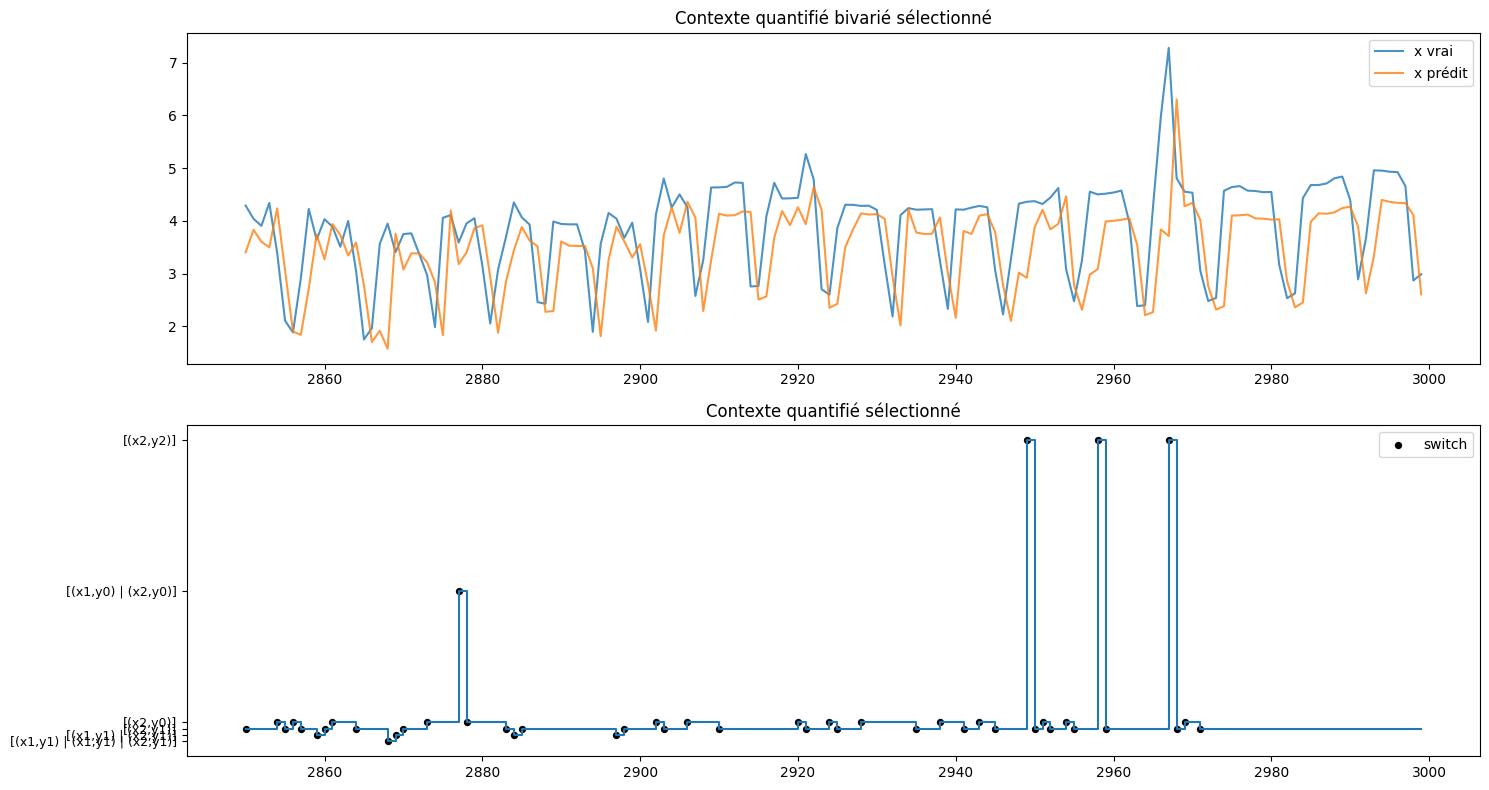

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [ ]:
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

# il faut récupérer le quantizer du modèle bivarié
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)

plot_context_timeline(
    actuals=bi["actuals"],
    predictions=bi["predictions"],
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    kind="bivariate",
    window_plot=150,
    title="Contexte quantifié bivarié sélectionné",
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def _plot_threshold_lines(ax, thresholds, colors=None, prefix="thr"):
    thresholds = np.asarray(thresholds, dtype=float)

    if colors is None:
        base_colors = ["tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
        colors = [base_colors[i % len(base_colors)] for i in range(len(thresholds))]

    for i, thr in enumerate(thresholds):
        ax.axhline(thr, color=colors[i], linestyle="--", alpha=0.9, label=f"{prefix}{i}={thr:.3f}")


def plot_bivariate_context_with_thresholds_std(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Contexte bivarié et seuils de quantification",
):
    """
    Tout est affiché dans l'espace standardisé.
    Les thresholds du quantizer sont donc directement cohérents avec les séries tracées.
    """
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    x_test = x_scaled[split_idx:split_idx + len(actuals_scaled)]
    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    x_colors = ["tab:red", "tab:orange", "tab:pink", "tab:brown"]
    y_colors = ["tab:green", "tab:olive", "tab:cyan", "tab:blue"]

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(16, 11))

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(idx, actuals_scaled[s:n], label="x vrai (std)", color="black", linewidth=1.4, alpha=0.9)
    ax1.plot(idx, predictions_scaled[s:n], label="x prédit (std)", color="tab:red", alpha=0.8)
    _plot_threshold_lines(ax1, x_thr, colors=x_colors[:len(x_thr)], prefix="x_thr")
    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(idx, y_test[s:n], label="y (std)", color="tab:blue", alpha=0.85, marker='o')
    _plot_threshold_lines(ax2, y_thr, colors=y_colors[:len(y_thr)], prefix="y_thr")
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("Signal y standardisé et seuils de quantification")

    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.step(idx, codes[s:n], where="post", color="tab:purple")
    switch_mask = np.zeros(len(codes), dtype=bool)
    switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    switches = switches[(switches >= s) & (switches < n)]
    if len(switches) > 0:
        ax3.scatter(switches, codes[switches], s=18, color="black", label="switch")
        ax3.legend()

    visible_codes = np.unique(codes[s:n])
    if len(visible_codes) <= max_tick_labels:
        ax3.set_yticks(visible_codes)
        ax3.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax3.set_yticks(visible_codes)
        ax3.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax3.set_title("Contexte bivarié actif")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "x_thresholds": x_thr,
        "y_thresholds": y_thr,
    }


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def _plot_threshold_lines(ax, thresholds, colors=None, prefix="thr"):
    thresholds = np.asarray(thresholds, dtype=float)

    if colors is None:
        base_colors = ["tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
        colors = [base_colors[i % len(base_colors)] for i in range(len(thresholds))]

    for i, thr in enumerate(thresholds):
        ax.axhline(
            thr,
            color=colors[i],
            linestyle="--",
            alpha=0.9,
            linewidth=1.2,
            label=f"{prefix}{i}={thr:.3f}",
        )


def _compute_switches_from_contexts(contexts, quantizer=None, kind="bivariate", compact=True):
    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind=kind,
        compact=compact,
    )

    switch_mask = np.zeros(len(codes), dtype=bool)
    if len(codes) > 1:
        switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]

    return codes, code_to_label, switch_mask, switches


def _add_vertical_switch_lines(ax_list, switches, s, n, color="black", alpha=0.18, linestyle=":"):
    visible_switches = switches[(switches >= s) & (switches < n)]
    for ax in ax_list:
        for sw in visible_switches:
            ax.axvline(sw, color=color, linestyle=linestyle, alpha=alpha, linewidth=1.0)
    return visible_switches


def plot_bivariate_context_with_thresholds_std_markers(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Contexte bivarié et seuils de quantification",
):
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]
    errors = np.abs(predictions_scaled - actuals_scaled)

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    x_colors = ["tab:red", "tab:orange", "tab:pink", "tab:brown"]
    y_colors = ["tab:green", "tab:olive", "tab:cyan", "tab:blue"]

    codes, code_to_label, switch_mask, switches = _compute_switches_from_contexts(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    plt.figure(figsize=(16, 13))

    ax1 = plt.subplot(4, 1, 1)
    ax1.plot(
        idx, actuals_scaled[s:n],
        label="x vrai (std)",
        color="black",
        linewidth=1.4,
        alpha=0.9,
        marker="o",
        markersize=3,
    )
    ax1.plot(
        idx, predictions_scaled[s:n],
        label="x prédit (std)",
        color="tab:red",
        alpha=0.8,
        marker="s",
        markersize=3,
    )
    _plot_threshold_lines(ax1, x_thr, colors=x_colors[:len(x_thr)], prefix="x_thr")
    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    ax2.plot(
        idx, y_test[s:n],
        label="y (std)",
        color="tab:blue",
        alpha=0.85,
        marker="D",
        markersize=3,
    )
    _plot_threshold_lines(ax2, y_thr, colors=y_colors[:len(y_thr)], prefix="y_thr")
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("Signal y standardisé et seuils")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(
        idx, errors[s:n],
        label="|erreur|",
        color="tab:orange",
        alpha=0.9,
        marker="^",
        markersize=3,
    )
    ax3.legend(loc="best")
    ax3.set_title("Erreur absolue")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.step(idx, codes[s:n], where="post", color="tab:purple", linewidth=1.5)
    visible_switches = switches[(switches >= s) & (switches < n)]
    if len(visible_switches) > 0:
        ax4.scatter(
            visible_switches,
            codes[visible_switches],
            s=22,
            color="black",
            marker="x",
            label="switch régime",
            zorder=3,
        )
        ax4.legend()

    visible_codes = np.unique(codes[s:n])
    if len(visible_codes) <= max_tick_labels:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax4.set_title("Contexte bivarié actif")

    _add_vertical_switch_lines([ax1, ax2, ax3, ax4], switches, s, n)

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "switch_mask": switch_mask,
        "switches": switches,
        "x_thresholds": x_thr,
        "y_thresholds": y_thr,
    }


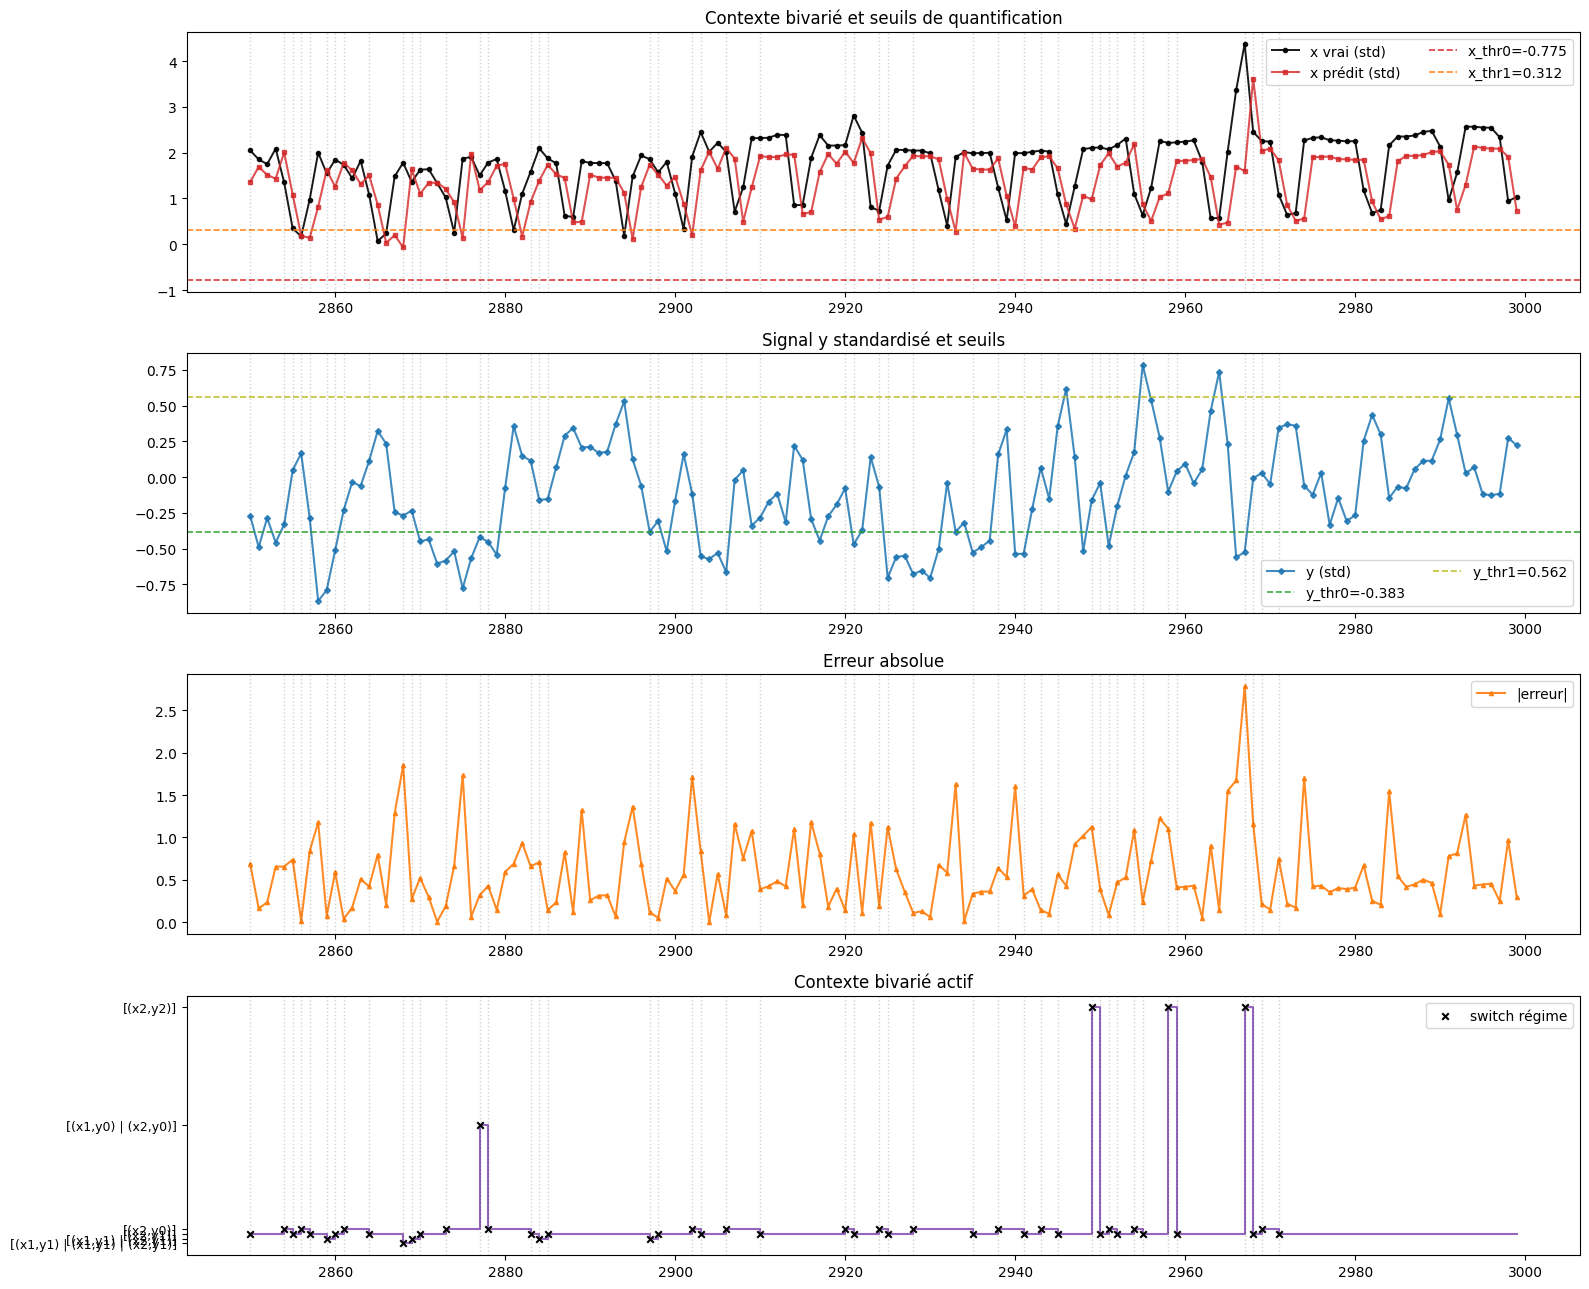

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [ ]:
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

actuals_bi_std = (bi["actuals"] - fit_bi["mu_x"]) / fit_bi["std_x"]
preds_bi_std = (bi["predictions"] - fit_bi["mu_x"]) / fit_bi["std_x"]

plot_bivariate_context_with_thresholds_std_markers(
    x_scaled=fit_bi["x_scaled"],
    y_scaled=fit_bi["y_scaled"],
    actuals_scaled=actuals_bi_std,
    predictions_scaled=preds_bi_std,
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    split_idx=bi["split_idx"],
    window_plot=150,
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_bivariate_context_with_regime_colors(
    x_scaled,
    y_scaled,
    actuals_scaled,
    predictions_scaled,
    contexts,
    quantizer,
    split_idx,
    window_plot=200,
    compact=True,
    max_tick_labels=12,
    title="Régimes bivariés actifs",
):
    x_scaled = np.asarray(x_scaled, dtype=float)
    y_scaled = np.asarray(y_scaled, dtype=float)
    actuals_scaled = np.asarray(actuals_scaled, dtype=float)
    predictions_scaled = np.asarray(predictions_scaled, dtype=float)

    y_test = y_scaled[split_idx:split_idx + len(actuals_scaled)]
    errors = np.abs(predictions_scaled - actuals_scaled)

    x_thr = np.asarray(quantizer.quantizers[0]._thresholds, dtype=float)
    y_thr = np.asarray(quantizer.quantizers[1]._thresholds, dtype=float)

    codes, code_to_label = contexts_to_codes_and_labels(
        contexts,
        quantizer=quantizer,
        kind="bivariate",
        compact=compact,
    )

    n = len(actuals_scaled)
    s = max(0, n - window_plot)
    idx = np.arange(s, n)

    visible_codes = np.unique(codes[s:n])
    cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))
    color_map = {c: cmap(i % cmap.N) for i, c in enumerate(visible_codes)}

    switch_mask = np.zeros(len(codes), dtype=bool)
    if len(codes) > 1:
        switch_mask[1:] = codes[1:] != codes[:-1]
    switches = np.where(switch_mask)[0]
    visible_switches = switches[(switches >= s) & (switches < n)]

    plt.figure(figsize=(16, 12))

    ax1 = plt.subplot(4, 1, 1)

    # zones colorées par régime
    start = s
    current = codes[s]
    for t in range(s + 1, n + 1):
        if t == n or codes[t] != current:
            ax1.axvspan(start, t - 1, color=color_map[current], alpha=0.18)
            if t < n:
                start = t
                current = codes[t]

    ax1.plot(
        idx, actuals_scaled[s:n],
        label="x vrai (std)",
        color="black",
        linewidth=1.4,
        alpha=0.9,
        marker="o",
        markersize=3,
    )
    ax1.plot(
        idx, predictions_scaled[s:n],
        label="x prédit (std)",
        color="tab:red",
        alpha=0.8,
        marker="s",
        markersize=3,
    )

    for i, thr in enumerate(x_thr):
        ax1.axhline(
            thr,
            color=["tab:red", "tab:orange", "tab:pink", "tab:brown"][i % 4],
            linestyle="--",
            alpha=0.9,
            linewidth=1.1,
            label=f"x_thr{i}={thr:.3f}",
        )

    for sw in visible_switches:
        ax1.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)

    ax1.legend(loc="best", ncol=2)
    ax1.set_title(title)

    ax2 = plt.subplot(4, 1, 2, sharex=ax1)
    ax2.plot(
        idx, y_test[s:n],
        label="y (std)",
        color="tab:blue",
        alpha=0.85,
        marker="D",
        markersize=3,
    )
    for i, thr in enumerate(y_thr):
        ax2.axhline(
            thr,
            color=["tab:green", "tab:olive", "tab:cyan", "tab:blue"][i % 4],
            linestyle="--",
            alpha=0.9,
            linewidth=1.1,
            label=f"y_thr{i}={thr:.3f}",
        )
    for sw in visible_switches:
        ax2.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)
    ax2.legend(loc="best", ncol=2)
    ax2.set_title("y standardisé")

    ax3 = plt.subplot(4, 1, 3, sharex=ax1)
    ax3.plot(
        idx, errors[s:n],
        label="|erreur|",
        color="tab:orange",
        alpha=0.9,
        marker="^",
        markersize=3,
    )
    for sw in visible_switches:
        ax3.axvline(sw, color="black", linestyle=":", alpha=0.2, linewidth=1.0)
    ax3.legend(loc="best")
    ax3.set_title("Erreur absolue")

    ax4 = plt.subplot(4, 1, 4, sharex=ax1)
    ax4.step(idx, codes[s:n], where="post", color="tab:purple", linewidth=1.5)
    if len(visible_switches) > 0:
        ax4.scatter(
            visible_switches,
            codes[visible_switches],
            s=24,
            color="black",
            marker="x",
            label="switch régime",
            zorder=3,
        )
        ax4.legend()

    if len(visible_codes) <= max_tick_labels:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([code_to_label[c] for c in visible_codes], fontsize=9)
    else:
        ax4.set_yticks(visible_codes)
        ax4.set_yticklabels([str(c) for c in visible_codes], fontsize=9)
        print("Correspondance code -> contexte visible :")
        for c in visible_codes:
            print(f"  {c}: {code_to_label[c]}")

    ax4.set_title("Contexte quantifié actif")

    plt.tight_layout()
    plt.show()

    return {
        "codes": codes,
        "code_to_label": code_to_label,
        "visible_codes": visible_codes,
        "switches": switches,
        "color_map": color_map,
    }


/var/folders/dr/v65kt4vd74b0bqgk5_sy5npr0000gn/T/ipykernel_308/3210989227.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(20, len(visible_codes)))


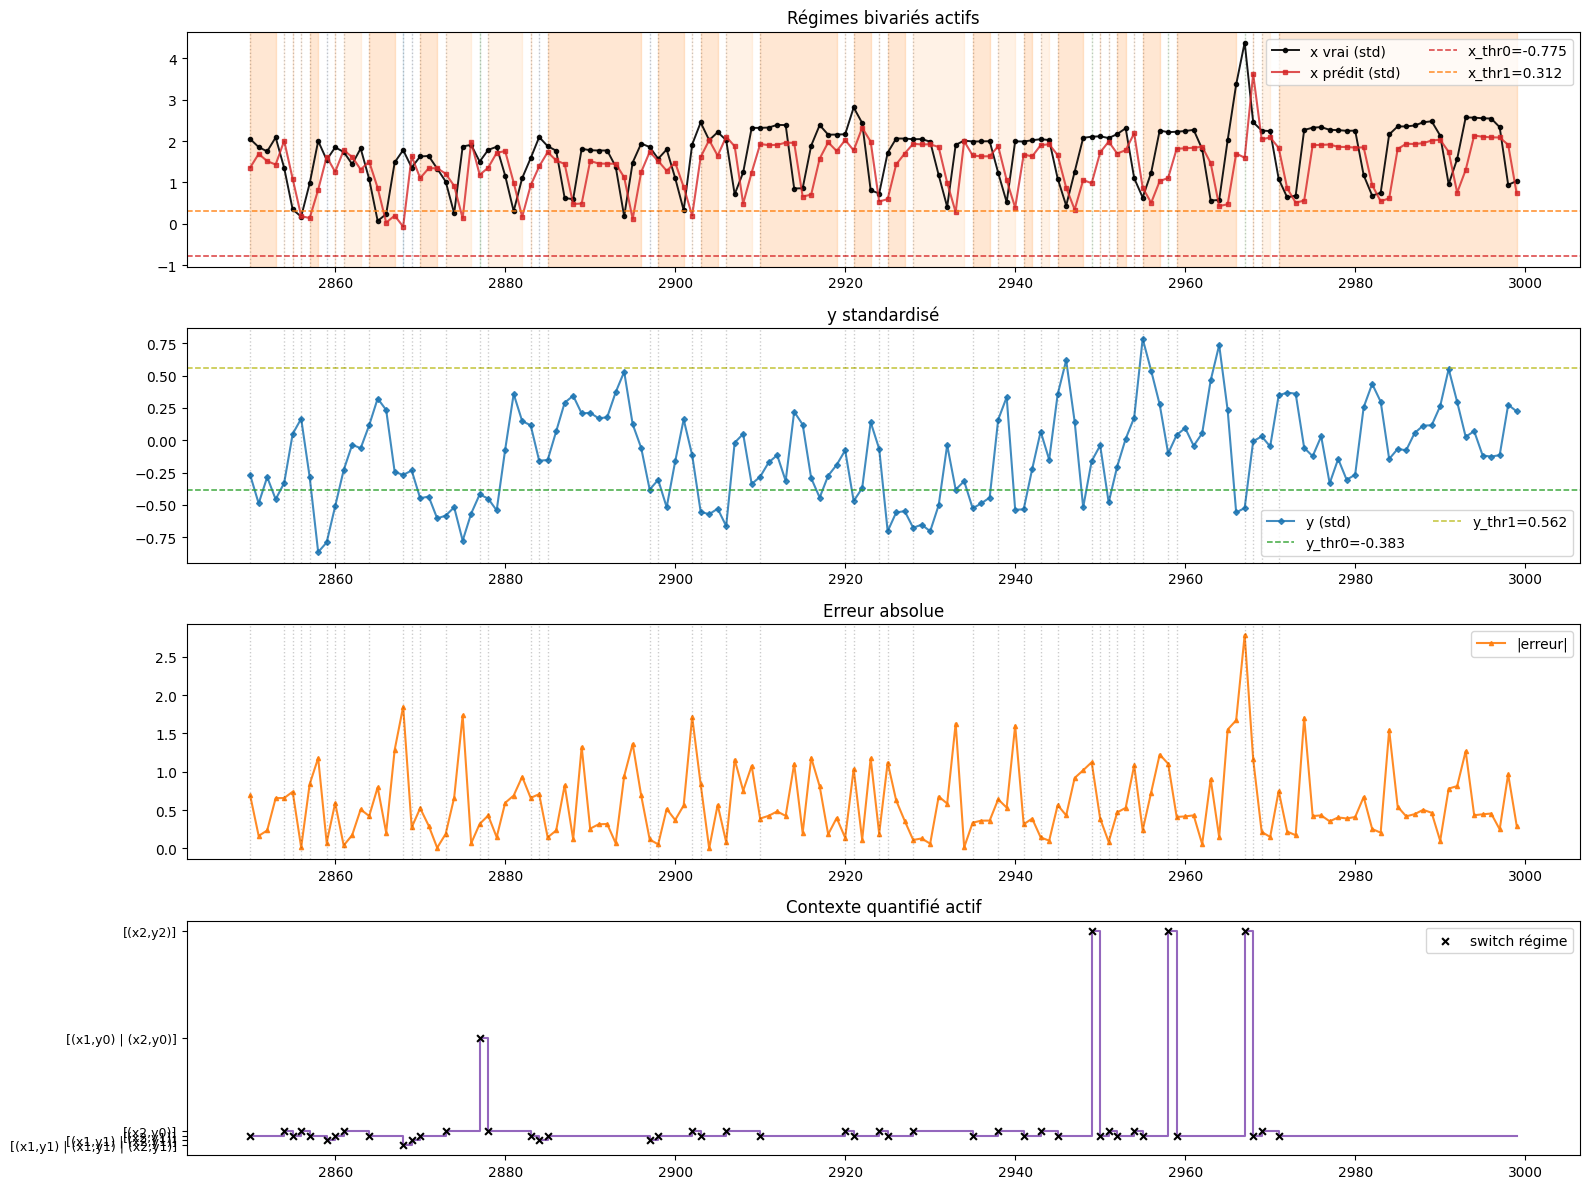

{'codes': array([0, 0, 0, ..., 5, 5, 5], shape=(3000,)),
 'code_to_label': {0: '[(x1,y2) | (x1,y2) | (x1,y2)]',
  1: '[(x1,y2) | (x1,y2) | (x1,y1)]',
  2: '[(x1,y2) | (x1,y1)]',
  3: '[(x1,y1) | (x1,y1) | (x2,y1)]',
  4: '[(x1,y1) | (x2,y1)]',
  5: '[(x2,y1)]',
  6: '[(x2,y0)]',
  7: '[(x1,y1) | (x1,y1) | (x1,y1)]',
  8: '[(x1,y1) | (x1,y1) | (x1,y2)]',
  9: '[(x1,y1) | (x1,y2)]',
  10: '[(x1,y1) | (x1,y1) | (x0,y2)]',
  11: '[(x1,y1) | (x0,y2) | (x0,y2)]',
  12: '[(x0,y2) | (x0,y2) | (x0,y2)]',
  13: '[(x0,y2) | (x0,y2) | (x0,y1)]',
  14: '[(x0,y2) | (x0,y1)]',
  15: '[(x0,y1) | (x0,y1) | (x0,y1)]',
  16: '[(x0,y1) | (x0,y1) | (x0,y2)]',
  17: '[(x0,y1) | (x0,y2)]',
  18: '[(x0,y1) | (x1,y1)]',
  19: '[(x1,y1) | (x1,y1) | (x1,y0)]',
  20: '[(x1,y1) | (x1,y0)]',
  21: '[(x1,y0) | (x1,y1)]',
  22: '[(x1,y0) | (x1,y0) | (x1,y0)]',
  23: '[(x1,y0) | (x1,y0) | (x0,y0)]',
  24: '[(x1,y0) | (x0,y0) | (x0,y0)]',
  25: '[(x0,y0)]',
  26: '[(x1,y0) | (x1,y0) | (x2,y0)]',
  27: '[(x1,y0) | (x2,y

In [ ]:
fit_bi = fit_bivariate_for_trace(seq_x, seq_y, split=0.7)
bi = trace_bivariate_regimes(seq_x, seq_y, split=0.7, online=False)

actuals_bi_std = (bi["actuals"] - fit_bi["mu_x"]) / fit_bi["std_x"]
preds_bi_std = (bi["predictions"] - fit_bi["mu_x"]) / fit_bi["std_x"]

plot_bivariate_context_with_regime_colors(
    x_scaled=fit_bi["x_scaled"],
    y_scaled=fit_bi["y_scaled"],
    actuals_scaled=actuals_bi_std,
    predictions_scaled=preds_bi_std,
    contexts=bi["contexts"],
    quantizer=fit_bi["quantizer"],
    split_idx=bi["split_idx"],
    window_plot=150,
)
